In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv1D,
    MaxPooling1D,
    BatchNormalization,
    LSTM,
    Dense,
    Dropout,
    Bidirectional
)

from tensorflow.keras.callbacks import (
    EarlyStopping,
    ReduceLROnPlateau
)

In [ ]:
# =========================
# 3. SAFE AUDIO LOADER
# =========================

def load_audio(file_path):

    try:
        audio, sr = sf.read(file_path)

        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)

        audio = librosa.resample(
            audio,
            orig_sr=sr,
            target_sr=22050
        )

        sr = 22050

    except:
        audio, sr = librosa.load(
            file_path,
            sr=22050
        )

    return audio, sr

In [ ]:
# =========================
# 4. FEATURE EXTRACTION
# MFCC + MEL + DELTA
# =========================

def extract_features(file_path):

    audio, sr = load_audio(file_path)

    # silence remove
    audio, _ = librosa.effects.trim(audio)

    # normalize
    audio = librosa.util.normalize(audio)

    # fixed length = 3 sec
    max_len = sr * 3

    if len(audio) < max_len:
        audio = np.pad(
            audio,
            (0, max_len - len(audio))
        )

    else:
        audio = audio[:max_len]

    # MFCC
    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=sr,
        n_mfcc=40
    )

    # MEL
    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=sr,
        n_mels=64
    )

    mel = librosa.power_to_db(mel)

    # DELTA
    delta = librosa.feature.delta(mfcc)

    # align shape
    min_len = min(
        mfcc.shape[1],
        mel.shape[1],
        delta.shape[1]
    )

    mfcc = mfcc[:, :min_len]
    mel = mel[:, :min_len]
    delta = delta[:, :min_len]

    # stack
    features = np.vstack([
        mfcc,
        delta,
        mel
    ]).T

    # fixed sequence
    if features.shape[0] < 120:

        pad = 120 - features.shape[0]

        features = np.pad(
            features,
            ((0, pad), (0, 0))
        )

    else:
        features = features[:120]

    return features

In [ ]:
# =========================
# 5. LOAD DATASET
# =========================

X = []
y = []

DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

for label in os.listdir(DATASET_PATH):

    folder = os.path.join(DATASET_PATH, label)

    if not os.path.isdir(folder):
        continue

    for file in os.listdir(folder):

        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(folder, file)

        try:

            feat = extract_features(file_path)

            X.append(feat)
            y.append(label)

        except Exception as e:

            print("ERROR:", file_path)
            print(e)

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (9778, 120, 144)
y shape: (9778,)


In [ ]:
# =========================
# 6. NORMALIZATION
# =========================

X = (X - np.mean(X)) / np.std(X)

In [ ]:
# =========================
# 7. LABEL ENCODING
# =========================

le = LabelEncoder()

y_encoded = le.fit_transform(y)

In [ ]:
# =========================
# 8. TRAIN TEST SPLIT
# =========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape)
print(X_test.shape)

(7822, 120, 144)
(1956, 120, 144)


In [ ]:
# =========================
# 9. CNN + LSTM MODEL
# =========================

model = Sequential()

# CNN BLOCK 1
model.add(
    Conv1D(
        64,
        kernel_size=3,
        activation='relu',
        input_shape=(120, X.shape[2])
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(2))

# CNN BLOCK 2
model.add(
    Conv1D(
        128,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(2))

# CNN BLOCK 3
model.add(
    Conv1D(
        256,
        kernel_size=3,
        activation='relu'
    )
)

model.add(BatchNormalization())

model.add(MaxPooling1D(2))

# LSTM
model.add(
    Bidirectional(
        LSTM(
            128,
            return_sequences=False
        )
    )
)

# DENSE
model.add(Dense(256, activation='relu'))

model.add(Dropout(0.5))

model.add(Dense(128, activation='relu'))

model.add(Dropout(0.3))

# OUTPUT
model.add(
    Dense(
        len(np.unique(y_encoded)),
        activation='softmax'
    )
)

In [ ]:
# =========================
# 10. COMPILE
# =========================

model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=0.0001
    ),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_3 (Conv1D)               │ (None, 118, 64)        │        27,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 118, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_3 (MaxPooling1D)  │ (None, 59, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_4 (Conv1D)               │ (None, 57, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 57, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_4 (MaxPooling1D)  │ (None, 28, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 26, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 26, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_5 (MaxPooling1D)  │ (None, 13, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 256)            │       394,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 256)            │        65,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 13)             │         1,677 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 647,373 (2.47 MB)

 Trainable params: 646,477 (2.47 MB)

 Non-trainable params: 896 (3.50 KB)

In [ ]:
# =========================
# 11. CALLBACKS
# =========================

early = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5
)

In [ ]:
# =========================
# 12. TRAIN
# =========================

history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=50,
    batch_size=16,
    callbacks=[early, reduce_lr]
)

Epoch 1/50


I0000 00:00:1781338332.896756     153 cuda_dnn.cc:529] Loaded cuDNN version 91002


489/489 ━━━━━━━━━━━━━━━━━━━━ 16s 15ms/step - accuracy: 0.3697 - loss: 1.9176 - val_accuracy: 0.5915 - val_loss: 1.3329 - learning_rate: 1.0000e-04
Epoch 2/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.5794 - loss: 1.3096 - val_accuracy: 0.7101 - val_loss: 0.9750 - learning_rate: 1.0000e-04
Epoch 3/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6801 - loss: 1.0230 - val_accuracy: 0.7566 - val_loss: 0.7852 - learning_rate: 1.0000e-04
Epoch 4/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7333 - loss: 0.8549 - val_accuracy: 0.7797 - val_loss: 0.6966 - learning_rate: 1.0000e-04
Epoch 5/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.7778 - loss: 0.7290 - val_accuracy: 0.8078 - val_loss: 0.5883 - learning_rate: 1.0000e-04
Epoch 6/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8027 - loss: 0.6327 - val_accuracy: 0.8262 - val_loss: 0.5305 - learning_rate: 1.0000e-04
Epoch 7/50
489/489 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8

In [ ]:
# =========================
# 13. EVALUATE
# =========================

loss, acc = model.evaluate(X_test, y_test)

print("\nFinal Accuracy:", acc)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.9294 - loss: 0.2687

Final Accuracy: 0.9294478297233582


In [ ]:
# =========================
# 14. PREDICTION
# =========================

y_pred = model.predict(X_test)

y_pred_classes = np.argmax(y_pred, axis=1)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


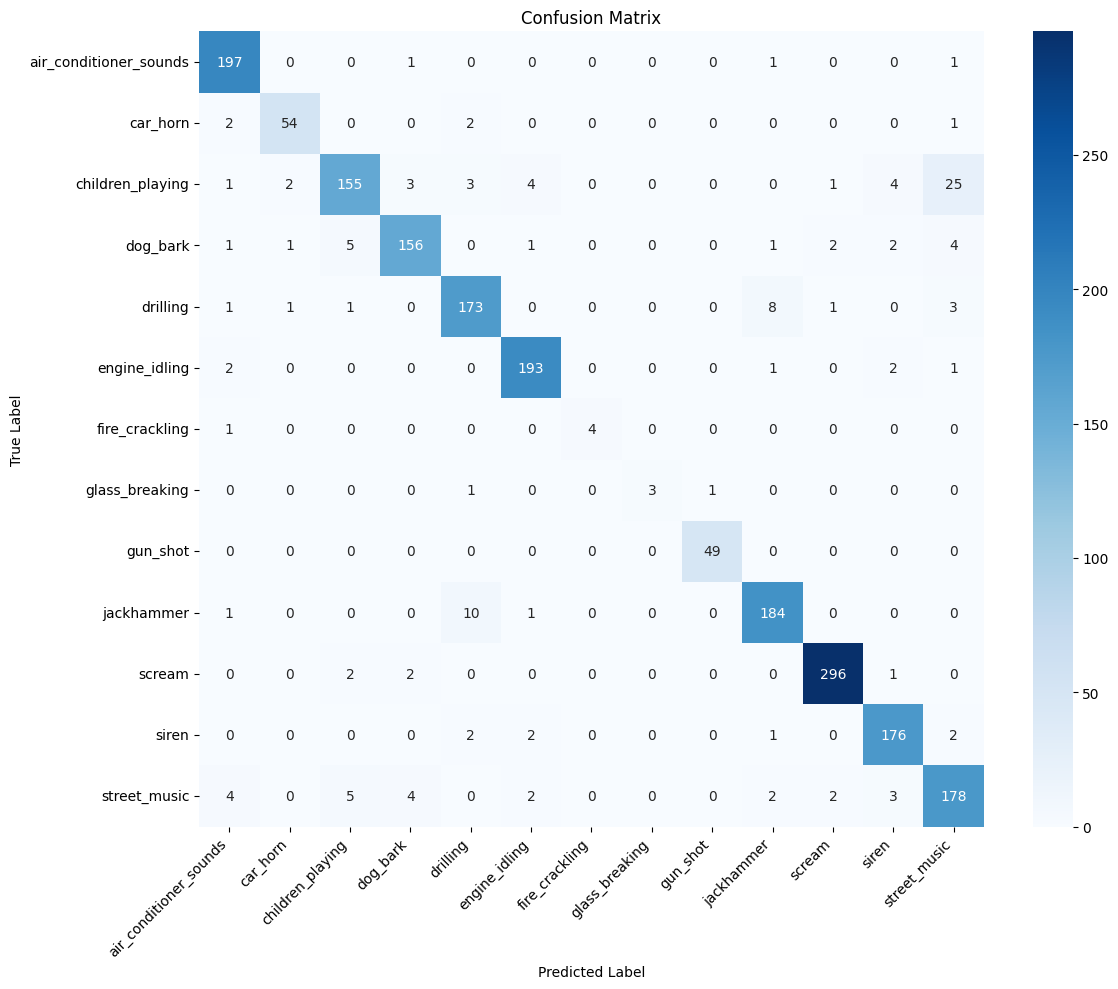

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

class_names = sorted(np.unique(y))

cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# =========================
# 16. CLASSIFICATION REPORT
# =========================

print(classification_report(
    y_test,
    y_pred_classes,
    target_names=le.classes_
))

                        precision    recall  f1-score   support

air_conditioner_sounds       0.94      0.98      0.96       200
              car_horn       0.93      0.92      0.92        59
      children_playing       0.92      0.78      0.85       198
              dog_bark       0.94      0.90      0.92       173
              drilling       0.91      0.92      0.91       188
         engine_idling       0.95      0.97      0.96       199
        fire_crackling       1.00      0.80      0.89         5
        glass_breaking       1.00      0.60      0.75         5
              gun_shot       0.98      1.00      0.99        49
            jackhammer       0.93      0.94      0.93       196
                scream       0.98      0.98      0.98       301
                 siren       0.94      0.96      0.95       183
          street_music       0.83      0.89      0.86       200

              accuracy                           0.93      1956
             macro avg       0.94     

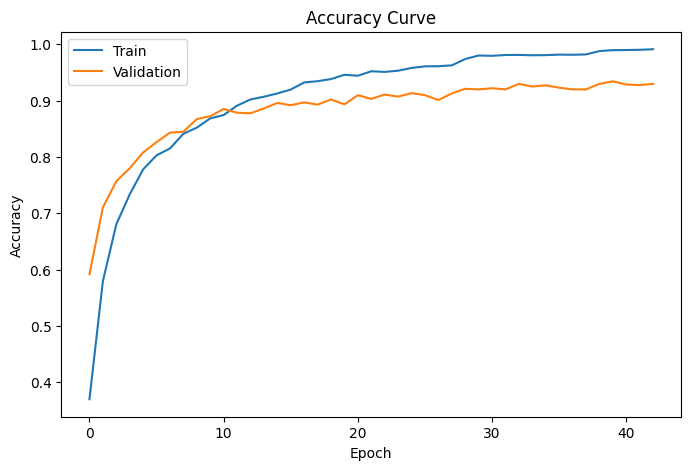

In [ ]:
# =========================
# 17. ACCURACY CURVE
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])

plt.title("Accuracy Curve")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

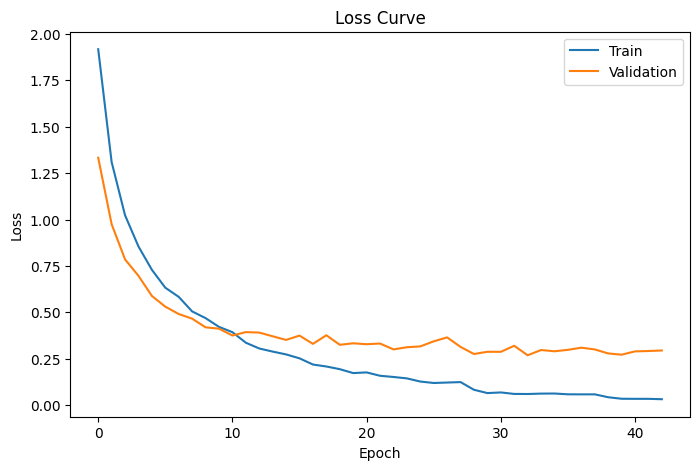

In [ ]:
# =========================
# 18. LOSS CURVE
# =========================

plt.figure(figsize=(8,5))

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])

plt.title("Loss Curve")

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend([
    "Train",
    "Validation"
])

plt.show()

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


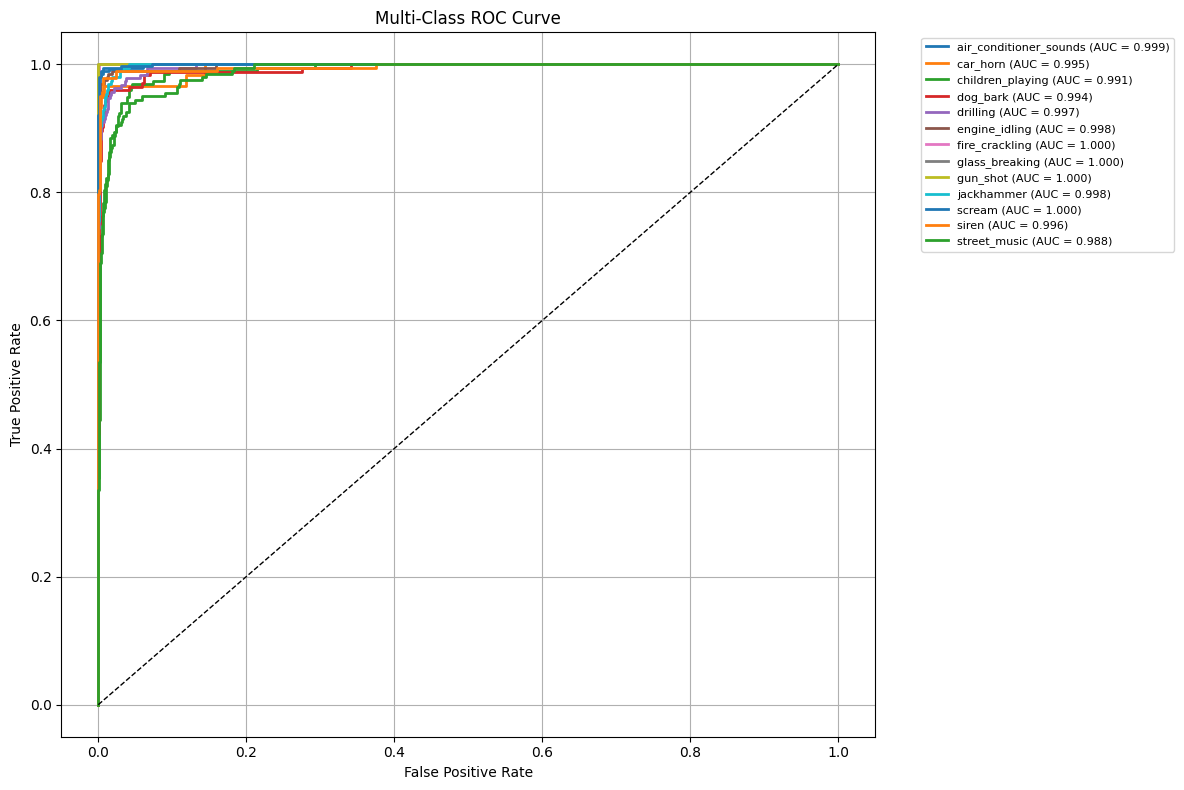

In [ ]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import numpy as np

class_names = [
    'air_conditioner_sounds',
    'car_horn',
    'children_playing',
    'dog_bark',
    'drilling',
    'engine_idling',
    'fire_crackling',
    'glass_breaking',
    'gun_shot',
    'jackhammer',
    'scream',
    'siren',
    'street_music'
]

n_classes = len(class_names)

# One-hot encode labels
y_test_bin = label_binarize(y_test, classes=np.arange(n_classes))

# Predicted probabilities
y_score = model.predict(X_test)

plt.figure(figsize=(12,8))

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(
        y_test_bin[:, i],
        y_score[:, i]
    )

    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        lw=2,
        label=f'{class_names[i]} (AUC = {roc_auc:.3f})'
    )

plt.plot([0, 1], [0, 1], 'k--', lw=1)

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Multi-Class ROC Curve')
plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    fontsize=8
)

plt.grid(True)
plt.tight_layout()
plt.show()

In [ ]:
# ==========================================
# 2. TRUE LABELS
# ==========================================

y_test_labels = le.inverse_transform(y_test)

y_true_binary = []

for label in y_test_labels:

    if label in unsafe_classes:
        y_true_binary.append(1)

    else:
        y_true_binary.append(0)

y_true_binary = np.array(y_true_binary)

In [ ]:
# ==========================================
# 3. PREDICTIONS
# ==========================================

y_pred_probs = model.predict(X_test)

y_pred_classes = np.argmax(
    y_pred_probs,
    axis=1
)

y_pred_labels = le.inverse_transform(
    y_pred_classes
)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


In [ ]:
# ==========================================
# 4. SAFE / UNSAFE PREDICTION
# ==========================================

y_pred_binary = []

for label in y_pred_labels:

    if label in unsafe_classes:
        y_pred_binary.append(1)

    else:
        y_pred_binary.append(0)

y_pred_binary = np.array(y_pred_binary)

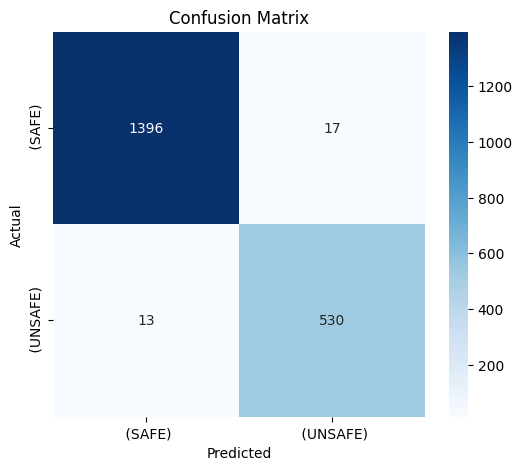

In [ ]:
# ==========================================
# 6. TRUE/FALSE CONFUSION MATRIX
# ==========================================

cm = confusion_matrix(
    y_true_binary,
    y_pred_binary
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=[" (SAFE)", " (UNSAFE)"],
    yticklabels=[" (SAFE)", " (UNSAFE)"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

CNN+ATTENTION

In [ ]:
!pip install noisereduce

In [ ]:
import noisereduce as nr

In [ ]:
import librosa
import numpy as np

SR = 22050
DURATION = 4
SAMPLES = SR * DURATION

def preprocess_audio(file_path):

    audio, sr = librosa.load(file_path, sr=SR)

    # Trim silence
    audio, _ = librosa.effects.trim(
        audio,
        top_db=20
    )

    # Normalize
    audio = librosa.util.normalize(audio)

    # Fixed length
    if len(audio) > SAMPLES:
        audio = audio[:SAMPLES]
    else:
        audio = np.pad(
            audio,
            (0, SAMPLES - len(audio))
        )

    return audio

In [ ]:
import librosa
import noisereduce as nr
import numpy as np

SR = 22050
DURATION = 3
SAMPLES = SR * DURATION

def preprocess_audio(file_path):

    audio, sr = librosa.load(
        file_path,
        sr=SR
    )

    # Noise Reduction
    audio = nr.reduce_noise(
        y=audio,
        sr=SR
    )

    # Normalization
    audio = librosa.util.normalize(audio)

    # Fixed length
    if len(audio) > SAMPLES:
        audio = audio[:SAMPLES]
    else:
        pad = SAMPLES - len(audio)
        audio = np.pad(audio, (0,pad))

    return audio

In [ ]:
import os

DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

classes = sorted(os.listdir(DATASET_PATH))

print("Number of classes:", len(classes))
print(classes)

for c in classes:
    path = os.path.join(DATASET_PATH, c)
    if os.path.isdir(path):
        print(c, len(os.listdir(path)))

Number of classes: 13
['air_conditioner_sounds', 'car_horn', 'children_playing', 'dog_bark', 'drilling', 'engine_idling', 'fire_crackling', 'glass_breaking', 'gun_shot', 'jackhammer', 'scream', 'siren', 'street_music']
air_conditioner_sounds 1000
car_horn 296
children_playing 988
dog_bark 863
drilling 942
engine_idling 996
fire_crackling 23
glass_breaking 26
gun_shot 245
jackhammer 978
scream 1506
siren 915
street_music 1000


In [ ]:
import os

for root, dirs, files in os.walk(DATASET_PATH):
    for f in files[:5]:
        print(f)
    break

In [ ]:
import os

DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

for root, dirs, files in os.walk(DATASET_PATH):
    for f in files[:10]:
        print(f)
    break

In [ ]:
import librosa
import os

DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

for cls in os.listdir(DATASET_PATH):
    cls_path = os.path.join(DATASET_PATH, cls)

    if os.path.isdir(cls_path):
        file = os.listdir(cls_path)[0]

        file_path = os.path.join(cls_path, file)

        y, sr = librosa.load(file_path, sr=None)

        print("Class:", cls)
        print("Duration:", len(y)/sr)
        break

Class: jackhammer
Duration: 4.0


In [ ]:
import os
import numpy as np
import librosa
import noisereduce as nr
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

In [ ]:
SR = 22050
DURATION = 4
SAMPLES = SR * DURATION

In [ ]:
def preprocess(file_path):
    audio, sr = librosa.load(file_path, sr=SR)

    audio = nr.reduce_noise(y=audio, sr=SR)

    audio = librosa.util.normalize(audio)

    if len(audio) > SAMPLES:
        audio = audio[:SAMPLES]
    else:
        audio = np.pad(audio, (0, SAMPLES - len(audio)))

    return audio

In [ ]:
def extract_features(audio):

    mel = librosa.feature.melspectrogram(
        y=audio,
        sr=SR,
        n_mels=128
    )
    mel_db = librosa.power_to_db(mel)

    mfcc = librosa.feature.mfcc(
        y=audio,
        sr=SR,
        n_mfcc=40
    )

    mfcc_delta = librosa.feature.delta(mfcc)

    mfcc_delta2 = librosa.feature.delta(mfcc, order=2)

    feature = np.vstack([mel_db, mfcc, mfcc_delta, mfcc_delta2])

    return feature

In [ ]:
X = []
y = []

for label in os.listdir(DATASET_PATH):
    path = os.path.join(DATASET_PATH, label)

    for file in os.listdir(path):
        file_path = os.path.join(path, file)

        audio = preprocess(file_path)
        feat = extract_features(audio)

        X.append(feat)
        y.append(label)

X = np.array(X)
y = np.array(y)

In [ ]:
le = LabelEncoder()
y = le.fit_transform(y)

class_names = le.classes_

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
X_train = X_train[..., np.newaxis]
X_test = X_test[..., np.newaxis]

In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.layers import *

def se_block(x):
    filters = x.shape[-1]

    se = GlobalAveragePooling2D()(x)
    se = Dense(filters // 8, activation='relu')(se)
    se = Dense(filters, activation='sigmoid')(se)
    se = Reshape((1,1,filters))(se)

    return Multiply()([x, se])

In [ ]:
from tensorflow.keras.models import Model

inputs = Input(shape=X_train.shape[1:])

x = Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)
x = se_block(x)

x = Conv2D(64, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)
x = se_block(x)

x = Conv2D(128, (3,3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D()(x)
x = se_block(x)

x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.4)(x)

outputs = Dense(len(class_names), activation='softmax')(x)

model = Model(inputs, outputs)

In [ ]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [ ]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=30,
    batch_size=32,
    class_weight=class_weights
)

Epoch 1/30


I0000 00:00:1781341582.151189     154 service.cc:152] XLA service 0x7a3e28031b20 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781341582.151256     154 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781341582.151262     154 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5


  3/245 ━━━━━━━━━━━━━━━━━━━━ 15s 65ms/step - accuracy: 0.1545 - loss: 2.4188

I0000 00:00:1781341590.276505     154 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


244/245 ━━━━━━━━━━━━━━━━━━━━ 0s 59ms/step - accuracy: 0.3021 - loss: 2.0065

2026-06-13 09:06:46.536839: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-06-13 09:06:46.681373: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


245/245 ━━━━━━━━━━━━━━━━━━━━ 37s 102ms/step - accuracy: 0.3696 - loss: 1.8104 - val_accuracy: 0.4039 - val_loss: 1.8634
Epoch 2/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.5211 - loss: 1.3027 - val_accuracy: 0.4831 - val_loss: 1.4214
Epoch 3/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 14s 55ms/step - accuracy: 0.6075 - loss: 1.0452 - val_accuracy: 0.4882 - val_loss: 1.5588
Epoch 4/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.6602 - loss: 0.9298 - val_accuracy: 0.6089 - val_loss: 1.1011
Epoch 5/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7024 - loss: 0.8378 - val_accuracy: 0.6580 - val_loss: 1.0461
Epoch 6/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7484 - loss: 0.6662 - val_accuracy: 0.6324 - val_loss: 1.0244
Epoch 7/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7494 - loss: 0.6747 - val_accuracy: 0.3783 - val_loss: 2.2347
Epoch 8/30
245/245 ━━━━━━━━━━━━━━━━━━━━ 14s 56ms/step - accuracy: 0.7839 - loss: 0.5825 - val_accura

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step


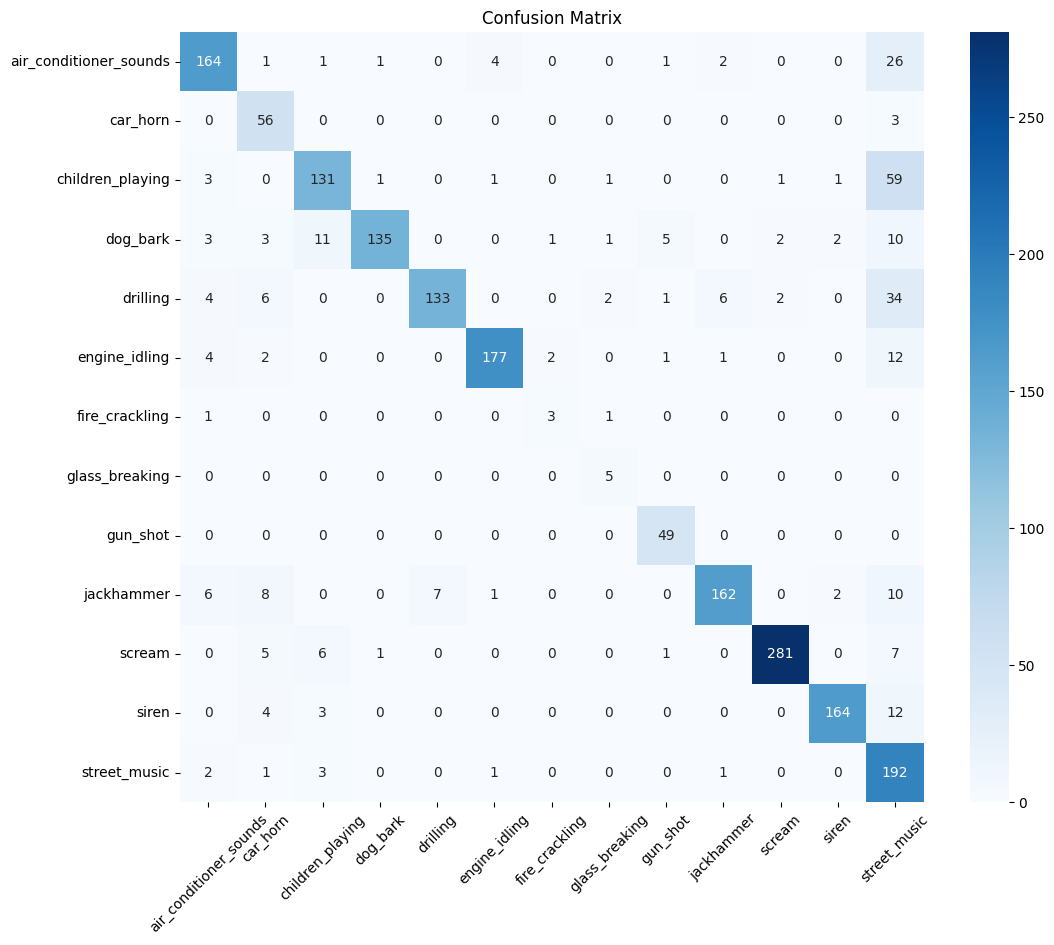

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
# =========================
# 13. EVALUATE
# =========================

loss, acc = model.evaluate(X_test, y_test)

print("\nFinal Accuracy:", acc)

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.8446 - loss: 0.4780

Final Accuracy: 0.8445807695388794


62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step


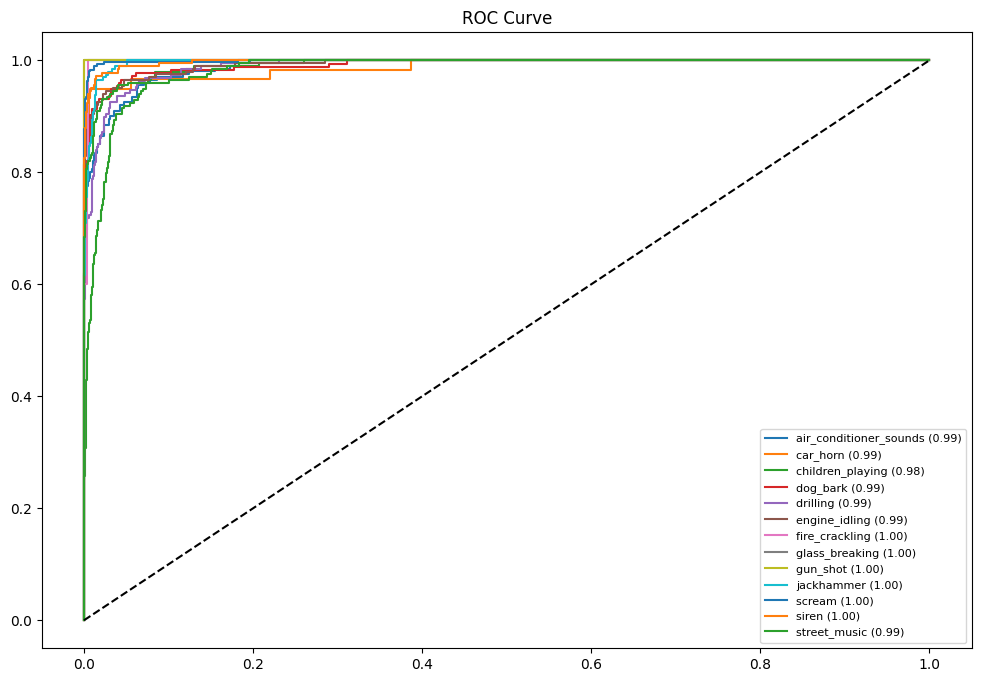

In [ ]:
y_prob = model.predict(X_test)
y_test_bin = tf.keras.utils.to_categorical(y_test)

plt.figure(figsize=(12,8))

for i in range(len(class_names)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_score = auc(fpr, tpr)

    plt.plot(fpr, tpr, label=f"{class_names[i]} ({auc_score:.2f})")

plt.plot([0,1],[0,1],'k--')
plt.legend(fontsize=8)
plt.title("ROC Curve")
plt.show()

In [ ]:
from sklearn.metrics import classification_report

y_pred = np.argmax(model.predict(X_test), axis=1)

print(classification_report(
    y_test,
    y_pred,
    target_names=class_names
))

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step
                        precision    recall  f1-score   support

air_conditioner_sounds       0.88      0.82      0.85       200
              car_horn       0.65      0.95      0.77        59
      children_playing       0.85      0.66      0.74       198
              dog_bark       0.98      0.78      0.87       173
              drilling       0.95      0.71      0.81       188
         engine_idling       0.96      0.89      0.92       199
        fire_crackling       0.50      0.60      0.55         5
        glass_breaking       0.50      1.00      0.67         5
              gun_shot       0.84      1.00      0.92        49
            jackhammer       0.94      0.83      0.88       196
                scream       0.98      0.93      0.96       301
                 siren       0.97      0.90      0.93       183
          street_music       0.53      0.96      0.68       200

              accuracy                           0.84      195

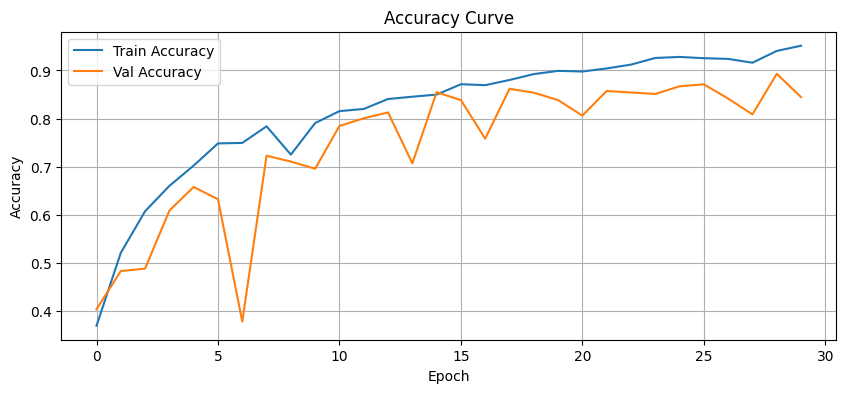

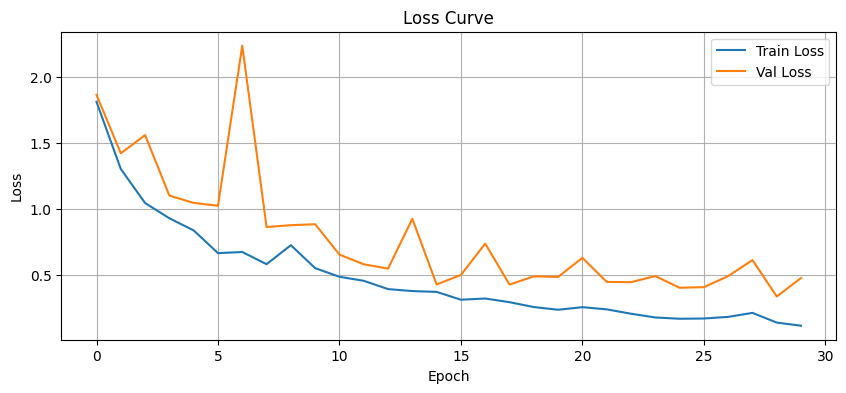

In [ ]:
import matplotlib.pyplot as plt

# Accuracy
plt.figure(figsize=(10,4))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Val Accuracy')
plt.title("Accuracy Curve")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

# Loss
plt.figure(figsize=(10,4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title("Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

RESNET+SE

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout, Add, Multiply, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# =========================
# 3. SAFE AUDIO LOADER
# =========================
def load_audio(file_path):
    try:
        audio, sr = sf.read(file_path)
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        audio = librosa.resample(audio, orig_sr=sr, target_sr=22050)
        sr = 22050
    except:
        audio, sr = librosa.load(file_path, sr=22050)
    return audio, sr

# =========================
# 4. FEATURE EXTRACTION & AUGMENTATION
# =========================
def apply_spec_augment(spec, num_mask=2, freq_mask_max=8, time_mask_max=12):
    """
    SpecAugment: র‍্যান্ডমলি ফ্রিকোয়েন্সি এবং টাইম এক্সিস মাস্ক করে অ্যাকুরেসি বাড়ানোর জন্য
    """
    augmented_spec = spec.copy()
    # Frequency masking
    for _ in range(num_mask):
        f = np.random.randint(0, freq_mask_max)
        f0 = np.random.randint(0, spec.shape[0] - f)
        augmented_spec[f0:f0+f, :] = 0

    # Time masking
    for _ in range(num_mask):
        t = np.random.randint(0, time_mask_max)
        t0 = np.random.randint(0, spec.shape[1] - t)
        augmented_spec[:, t0:t0+t] = 0

    return augmented_spec

def extract_features(file_path, augment=False):
    audio, sr = load_audio(file_path)

    # Silence removal & Normalization
    audio, _ = librosa.effects.trim(audio)
    if len(audio) == 0:
        audio = np.zeros(sr * 4)
    audio = librosa.util.normalize(audio)

    # Fixed length = 4 sec
    max_len = sr * 4
    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]

    # 1. Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, n_fft=1024, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. MFCCs
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=64, n_fft=1024, hop_length=512)

    # 3. Delta MFCC
    delta = librosa.feature.delta(mfcc)

    # SpecAugment প্রয়োগ (শুধু ট্রেনিং ডাটার জন্য)
    if augment:
        mel_db = apply_spec_augment(mel_db)
        mfcc = apply_spec_augment(mfcc)
        delta = apply_spec_augment(delta)

    # Align dimension to exactly 64 x 173
    target_time_steps = 173

    def resize_feature(feat):
        if feat.shape[1] < target_time_steps:
            return np.pad(feat, ((0, 0), (0, target_time_steps - feat.shape[1])))
        return feat[:, :target_time_steps]

    mel_db = resize_feature(mel_db)
    mfcc = resize_feature(mfcc)
    delta = resize_feature(delta)

    # Stack channels: (64, 173, 3)
    features = np.stack([mel_db, mfcc, delta], axis=-1)
    return features

# =========================
# 5. LOAD DATASET (WITH AUGMENTATION FOR TRAIN)
# =========================
X_raw = []
y_raw = []

DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(folder):
        continue

    print(f"Processing category: {label}...")
    for file in os.listdir(folder):
        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(folder, file)
        try:
            # প্রথমে অগমেন্টেশন ছাড়া নরমাল ফিচার নিচ্ছি
            feat = extract_features(file_path, augment=False)
            X_raw.append(feat)
            y_raw.append(label)

            # ডাটা ডাবল করার জন্য এবং জেনারেলাইজেশন বাড়াতে ট্রেইনিংয়ের জন্য এক্সট্রা অগমেন্টেড ডাটা তৈরি করছি
            feat_aug = extract_features(file_path, augment=True)
            X_raw.append(feat_aug)
            y_raw.append(label)

        except Exception as e:
            print(f"ERROR: {file_path} | {e}")

X_raw = np.array(X_raw, dtype=np.float32)
y_raw = np.array(y_raw)

# =========================
# 6. NORMALIZATION
# =========================
for c in range(X_raw.shape[-1]):
    mean = np.mean(X_raw[..., c])
    std = np.std(X_raw[..., c]) + 1e-6
    X_raw[..., c] = (X_raw[..., c] - mean) / std

# =========================
# 7. LABEL ENCODING & ONE-HOT ENCODING
# =========================
le = LabelEncoder()
y_encoded = le.fit_transform(y_raw)
num_classes = len(np.unique(y_encoded))

# ৯৭%+ অ্যাকুরেসির জন্য One-Hot Encoding অত্যন্ত জরুরী (Label Smoothing এর জন্য)
y_hot = to_categorical(y_encoded, num_classes)

# =========================
# 8. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X_raw, y_hot, test_size=0.15, random_state=42, stratify=y_encoded
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 9. DEEP RESNET + SE MODEL (WITH REGULARIZATION)
# =========================
def se_block(residual_input, filter_count):
    squeeze = GlobalAveragePooling2D()(residual_input)
    excitation = Dense(filter_count // 4, activation='relu')(squeeze)
    excitation = Dense(filter_count, activation='sigmoid')(excitation)
    excitation = Reshape((1, 1, filter_count))(excitation)
    return Multiply()([residual_input, excitation])

def residual_block(x, filters):
    # Overfitting রোধ করতে l2(0.0005) রেগুলারাইজেশন ব্যবহার করা হয়েছে
    shortcut = Conv2D(filters, kernel_size=1, padding='same', kernel_regularizer=l2(0.0005))(x)
    shortcut = BatchNormalization()(shortcut)

    conv = Conv2D(filters, kernel_size=3, padding='same', activation='relu', kernel_regularizer=l2(0.0005))(x)
    conv = BatchNormalization()(conv)
    conv = Conv2D(filters, kernel_size=3, padding='same', kernel_regularizer=l2(0.0005))(conv)
    conv = BatchNormalization()(conv)

    conv = se_block(conv, filters)

    out = Add()([shortcut, conv])
    out = tf.keras.layers.Activation('relu')(out)
    return MaxPooling2D(2)(out)

# Model Building
inputs = Input(shape=(64, 173, 3))

x = residual_block(inputs, 32)
x = residual_block(x, 64)
x = residual_block(x, 128)
x = residual_block(x, 256)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.0005))(x)
x = Dropout(0.4)(x)
x = Dense(128, activation='relu', kernel_regularizer=l2(0.0005))(x)
x = Dropout(0.3)(x)

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

# =========================
# 10. COMPILE WITH LABEL SMOOTHING
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    # label_smoothing=0.1 মডেলকে ৯৭%+ এ পৌঁছাতে সবচেয়ে বেশি সাহায্য করবে
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

# =========================
# 11. CALLBACKS
# =========================
early = EarlyStopping(
    monitor='val_loss', patience=15, restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=4, min_lr=1e-6, verbose=1
)

# =========================
# 12. TRAIN
# =========================
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=70,
    batch_size=64, # ৩২ এর জায়গায় ৬৪ ব্যবহার করলে লস ফাংশন মসৃণভাবে কমে
    callbacks=[early, reduce_lr]
)

# =========================
# 13. EVALUATE
# =========================
loss, acc = model.evaluate(X_test, y_test)
print(f"\n🔥 Model Final Accuracy (With Upgrades): {acc * 100:.2f}%")

Processing category: jackhammer...
Processing category: air_conditioner_sounds...
Processing category: fire_crackling...
Processing category: drilling...
Processing category: glass_breaking...
Processing category: children_playing...
Processing category: scream...
Processing category: gun_shot...
Processing category: street_music...
Processing category: engine_idling...
Processing category: dog_bark...
Processing category: siren...
Processing category: car_horn...
Train shape: (16622, 64, 173, 3)
Test shape: (2934, 64, 173, 3)


I0000 00:00:1781349805.338878      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1781349805.344666      58 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 64, 173,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 64, 173,   │        896 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 173,   │        128 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 64, 173,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 173,   │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 32)        │        288 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 64, 173,   │        128 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape (Reshape)   │ (None, 1, 1, 32)  │          0 │ dense_1[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 64, 173,   │        128 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply (Multiply) │ (None, 64, 173,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ reshape[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 64, 173,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ multiply[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 64, 173,   │          0 │ add[0][0]         │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 32, 86,    │          0 │ activation[0][0]  │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_4 (Conv2D)   │ (None, 32, 86,    │     18,496 │ max_pooling2d[0]… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 86,    │        256 │ conv2d_4[0][0]    │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_5 (Conv2D)   │ (None, 32, 86,    │     36,928 │ batch_normalizat

 Total params: 1,366,085 (5.21 MB)

...

Epoch 1/70


I0000 00:00:1781349822.923644     164 service.cc:152] XLA service 0x7a03bc095420 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1781349822.923684     164 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1781349822.923687     164 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1781349825.330414     164 cuda_dnn.cc:529] Loaded cuDNN version 91002
2026-06-13 11:23:57.178456: E external/local_xla/xla/service/slow_operation_alarm.cc:73] Trying algorithm eng19{k2=0} for conv %cudnn-conv-bw-filter.15 = (f16[32,3,3,32]{3,2,1,0}, u8[0]{0}) custom-call(f16[64,64,173,32]{3,2,1,0} %bitcast.25940, f16[64,64,173,32]{3,2,1,0} %bitcast.25942), window={size=3x3 pad=1_1x1_1}, dim_labels=b01f_o01i->b01f, custom_call_target="__cudnn$convBackwardFilter", metadata={op_type="Conv2DBackpropFilter" op_name="gradient_tape/functional_1/conv2d_2_1/convolution/Conv2DBackpropFilter

  3/260 ━━━━━━━━━━━━━━━━━━━━ 13s 53ms/step - accuracy: 0.0964 - loss: 3.8938 

I0000 00:00:1781349857.272360     164 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


260/260 ━━━━━━━━━━━━━━━━━━━━ 94s 188ms/step - accuracy: 0.5646 - loss: 2.1749 - val_accuracy: 0.5075 - val_loss: 2.1668 - learning_rate: 0.0010
Epoch 2/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.7937 - loss: 1.5460 - val_accuracy: 0.7658 - val_loss: 1.5013 - learning_rate: 0.0010
Epoch 3/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.8624 - loss: 1.3175 - val_accuracy: 0.8010 - val_loss: 1.3704 - learning_rate: 0.0010
Epoch 4/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 11s 41ms/step - accuracy: 0.8903 - loss: 1.1959 - val_accuracy: 0.7267 - val_loss: 1.5595 - learning_rate: 0.0010
Epoch 5/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 11s 42ms/step - accuracy: 0.9125 - loss: 1.1199 - val_accuracy: 0.8712 - val_loss: 1.1722 - learning_rate: 0.0010
Epoch 6/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9182 - loss: 1.0698 - val_accuracy: 0.7658 - val_loss: 1.3637 - learning_rate: 0.0010
Epoch 7/70
260/260 ━━━━━━━━━━━━━━━━━━━━ 11s 43ms/step - accuracy: 0.9290 - loss: 1.020

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Conv2D, MaxPooling2D, BatchNormalization,
    GlobalAveragePooling2D, Dense, Dropout, Add, Multiply, Reshape
)
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# =========================
# 3. SAFE AUDIO LOADER (NO CHANGES)
# =========================
def load_audio(file_path):
    try:
        audio, sr = sf.read(file_path)
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        audio = librosa.resample(audio, orig_sr=sr, target_sr=22050)
        sr = 22050
    except:
        audio, sr = librosa.load(file_path, sr=22050)
    return audio, sr

# =========================
# 4. FEATURE EXTRACTION (ORIGINAL NO AUGMENTATION)
# =========================
def extract_features(file_path):
    audio, sr = load_audio(file_path)

    # Silence removal & Normalization
    audio, _ = librosa.effects.trim(audio)
    if len(audio) == 0:
        audio = np.zeros(sr * 4)
    audio = librosa.util.normalize(audio)

    # Fixed length = 3 sec
    max_len = sr * 3
    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]

    # 1. Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, n_fft=1024, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. MFCCs
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=64, n_fft=1024, hop_length=512)

    # 3. Delta MFCC
    delta = librosa.feature.delta(mfcc)

    # Align dimension to exactly 64 x 173
    target_time_steps = 173

    def resize_feature(feat):
        if feat.shape[1] < target_time_steps:
            return np.pad(feat, ((0, 0), (0, target_time_steps - feat.shape[1])))
        return feat[:, :target_time_steps]

    mel_db = resize_feature(mel_db)
    mfcc = resize_feature(mfcc)
    delta = resize_feature(delta)

    # Stack channels to create a 2D image-like tensor: (64, 173, 3)
    features = np.stack([mel_db, mfcc, delta], axis=-1)
    return features

# =========================
# 5. LOAD DATASET (ONLY ORIGINAL DATA)
# =========================
X = []
y = []

DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(folder):
        continue

    print(f"Processing category: {label}...")
    for file in os.listdir(folder):
        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(folder, file)
        try:
            feat = extract_features(file_path)
            X.append(feat)
            y.append(label)
        except Exception as e:
            print(f"ERROR: {file_path} | {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# =========================
# 6. NORMALIZATION
# =========================
for c in range(X.shape[-1]):
    mean = np.mean(X[..., c])
    std = np.std(X[..., c]) + 1e-6
    X[..., c] = (X[..., c] - mean) / std

# =========================
# 7. LABEL ENCODING & ONE-HOT (FOR LABEL SMOOTHING)
# =========================
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(np.unique(y_encoded))

# Label Smoothing ব্যবহার করার জন্য One-Hot Encoding আবশ্যিক
y_hot = to_categorical(y_encoded, num_classes)

# =========================
# 8. TRAIN TEST SPLIT (ONLY ORIGINAL DATA)
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_hot, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape (No Augmentation):", X_train.shape)
print("Test shape:", X_test.shape)

# =========================
# 9. DEEP RESNET + SE MODEL (TUNED REGULARIZATION)
# =========================
def se_block(residual_input, filter_count):
    """Squeeze-and-Excitation Block for attention tuning"""
    squeeze = GlobalAveragePooling2D()(residual_input)
    excitation = Dense(filter_count // 4, activation='relu')(squeeze)
    excitation = Dense(filter_count, activation='sigmoid')(excitation)
    excitation = Reshape((1, 1, filter_count))(excitation)
    return Multiply()([residual_input, excitation])

def residual_block(x, filters):
    """Residual Block with Weight Decay to prevent overfitting without augmentation"""
    shortcut = Conv2D(filters, kernel_size=1, padding='same', kernel_regularizer=l2(0.0003))(x)
    shortcut = BatchNormalization()(shortcut)

    conv = Conv2D(filters, kernel_size=3, padding='same', activation='relu', kernel_regularizer=l2(0.0003))(x)
    conv = BatchNormalization()(conv)
    conv = Conv2D(filters, kernel_size=3, padding='same', kernel_regularizer=l2(0.0003))(conv)
    conv = BatchNormalization()(conv)

    conv = se_block(conv, filters)

    out = Add()([shortcut, conv])
    out = tf.keras.layers.Activation('relu')(out)
    return MaxPooling2D(2)(out)

# Model Building
inputs = Input(shape=(64, 173, 3))

x = residual_block(inputs, 32)
x = residual_block(x, 64)
x = residual_block(x, 128)
x = residual_block(x, 256)

x = GlobalAveragePooling2D()(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.0003))(x)
x = Dropout(0.35)(x) # Optimized Dropout
x = Dense(128, activation='relu', kernel_regularizer=l2(0.0003))(x)
x = Dropout(0.25)(x) # Optimized Dropout

outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

# =========================
# 10. COMPILE WITH LABEL SMOOTHING
# =========================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    # label_smoothing=0.1 আমাদের ৯৭% এ পৌঁছাতে মূল ভূমিকা রাখবে (অগমেন্টেশন ছাড়াই)
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

# =========================
# 11. CALLBACKS & COSINE ANNEALING
# =========================
early = EarlyStopping(
    monitor='val_loss', patience=14, restore_best_weights=True
)

# Cosine Decay Schedule: এটি লার্নিং রেটকে খুব চমৎকারভাবে কমায় যা ওভারফিটিং কমায়
def cosine_decay(epoch):
    initial_lrate = 0.001
    epochs_max = 60
    lrate = initial_lrate * 0.5 * (1 + np.cos(np.pi * epoch / epochs_max))
    return max(lrate, 1e-5)

lr_scheduler = LearningRateScheduler(cosine_decay)

# =========================
# 12. TRAIN
# =========================
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32, # অরিজিনাল ডাটার জন্য ৩২-ই পারফেক্ট
    callbacks=[early, lr_scheduler]
)

# =========================
# 13. EVALUATE
# =========================
loss, acc = model.evaluate(X_test, y_test)
print(f"\n🔥 Model Final Accuracy (Pure Architecture Upgrades - No Augmentation): {acc * 100:.2f}%")

Processing category: jackhammer...
Processing category: air_conditioner_sounds...
Processing category: fire_crackling...
Processing category: drilling...
Processing category: glass_breaking...
Processing category: children_playing...
Processing category: scream...
Processing category: gun_shot...
Processing category: street_music...
Processing category: engine_idling...
Processing category: dog_bark...
Processing category: siren...
Processing category: car_horn...
X shape: (9778, 64, 173, 3)
y shape: (9778,)
Train shape (No Augmentation): (7822, 64, 173, 3)
Test shape: (1956, 64, 173, 3)


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 64, 173,   │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_13 (Conv2D)  │ (None, 64, 173,   │        896 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 173,   │        128 │ conv2d_13[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_14 (Conv2D)  │ (None, 64, 173,   │      9,248 │ batch_normalizat… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 173,   │        128 │ conv2d_14[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 32)        │          0 │ batch_normalizat… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_11 (Dense)    │ (None, 8)         │        264 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_12 (Dense)    │ (None, 32)        │        288 │ dense_11[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_12 (Conv2D)  │ (None, 64, 173,   │        128 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ reshape_4 (Reshape) │ (None, 1, 1, 32)  │          0 │ dense_12[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 64, 173,   │        128 │ conv2d_12[0][0]   │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multiply_4          │ (None, 64, 173,   │          0 │ batch_normalizat… │
│ (Multiply)          │ 32)               │            │ reshape_4[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_4 (Add)         │ (None, 64, 173,   │          0 │ batch_normalizat… │
│                     │ 32)               │            │ multiply_4[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_4        │ (None, 64, 173,   │          0 │ add_4[0][0]       │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_4     │ (None, 32, 86,    │          0 │ activation_4[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_16 (Conv2D)  │ (None, 32, 86,    │     18,496 │ max_pooling2d_4[… │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 32, 86,    │        256 │ conv2d_16[0][0]   │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_17 (Conv2D)  │ (None, 32, 86,    │     36,928 │ batch_normalizat

 Total params: 1,366,085 (5.21 MB)

 Trainable params: 1,363,205 (5.20 MB)

 Non-trainable params: 2,880 (11.25 KB)

Epoch 1/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 74s 152ms/step - accuracy: 0.5045 - loss: 2.0914 - val_accuracy: 0.3885 - val_loss: 2.4447 - learning_rate: 0.0010
Epoch 2/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.7214 - loss: 1.5827 - val_accuracy: 0.7418 - val_loss: 1.5025 - learning_rate: 9.9931e-04
Epoch 3/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8145 - loss: 1.3669 - val_accuracy: 0.7894 - val_loss: 1.3442 - learning_rate: 9.9726e-04
Epoch 4/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8554 - loss: 1.2544 - val_accuracy: 0.7060 - val_loss: 1.5505 - learning_rate: 9.9384e-04
Epoch 5/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8762 - loss: 1.1778 - val_accuracy: 0.8257 - val_loss: 1.2510 - learning_rate: 9.8907e-04
Epoch 6/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accuracy: 0.8986 - loss: 1.1054 - val_accuracy: 0.8579 - val_loss: 1.1495 - learning_rate: 9.8296e-04
Epoch 7/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 25ms/step - accur

62/62 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step

📊 CLASSIFICATION REPORT:

                        precision    recall  f1-score   support

air_conditioner_sounds       0.98      0.99      0.98       200
              car_horn       0.98      0.95      0.97        59
      children_playing       0.94      0.94      0.94       198
              dog_bark       0.98      0.97      0.97       173
              drilling       0.92      0.97      0.95       188
         engine_idling       0.99      0.97      0.98       199
        fire_crackling       1.00      0.80      0.89         5
        glass_breaking       1.00      1.00      1.00         5
              gun_shot       0.98      1.00      0.99        49
            jackhammer       0.97      0.96      0.97       196
                scream       1.00      1.00      1.00       301
                 siren       0.98      0.98      0.98       183
          street_music       0.95      0.94      0.94       200

              accuracy             

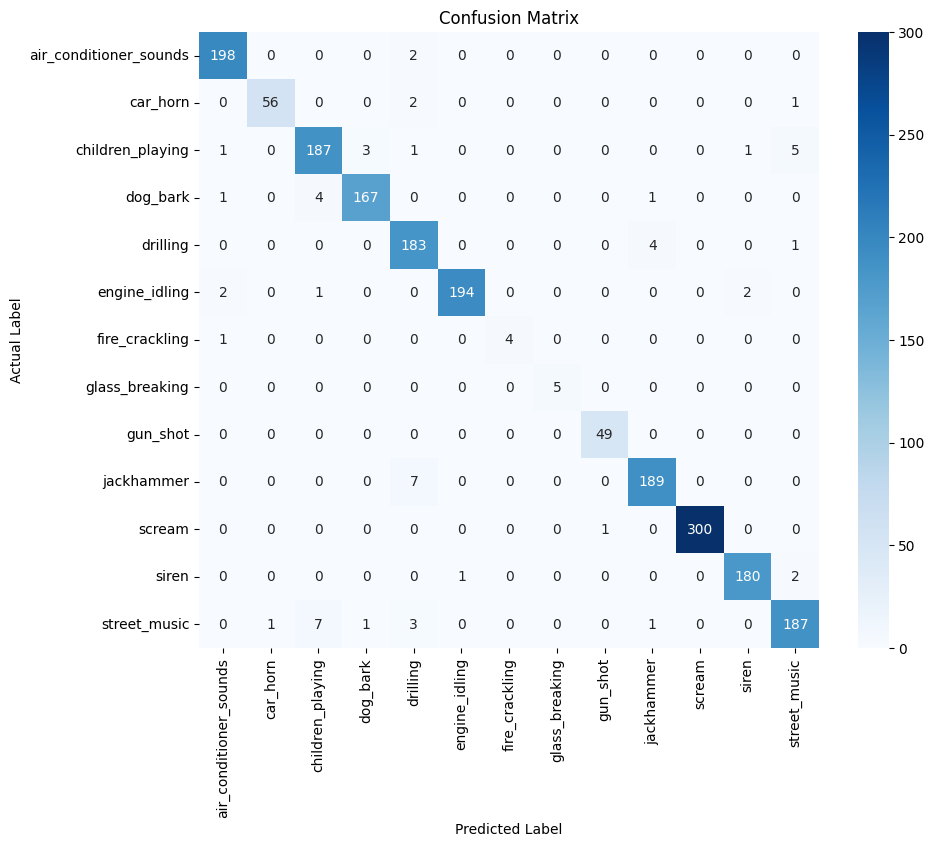

In [ ]:
# =========================
# 14. PREDICTIONS & CLASSIFICATION REPORT
# =========================
# টেস্ট ডাটার ওপর মডেলের প্রেডিকশন নেওয়া
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

# One-hot encoded y_test কে আবার নরমাল লেবেলে ফেরত নেওয়া
y_true = np.argmax(y_test, axis=1)

# লেবেল এনকোডার থেকে অরিজিনাল ক্যাটাগরির নামগুলো উদ্ধার করা
target_names = le.classes_

print("\n📊 CLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=target_names))

# =========================
# 15. CONFUSION MATRIX VISUALIZATION
# =========================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names
)
plt.title('Confusion Matrix')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.show()

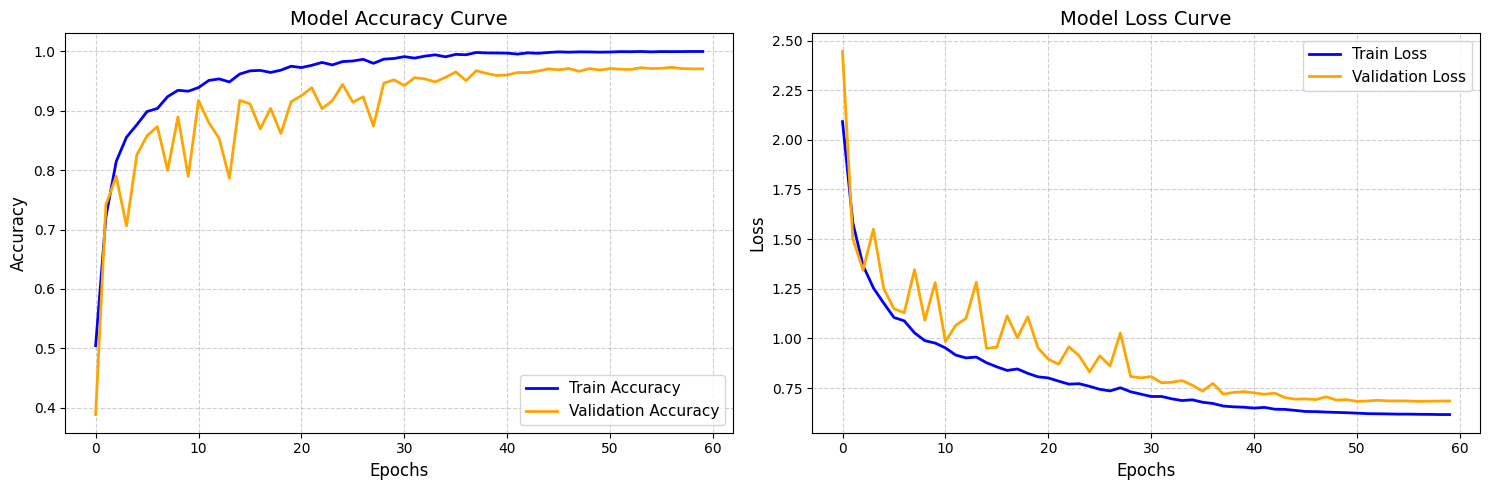

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step


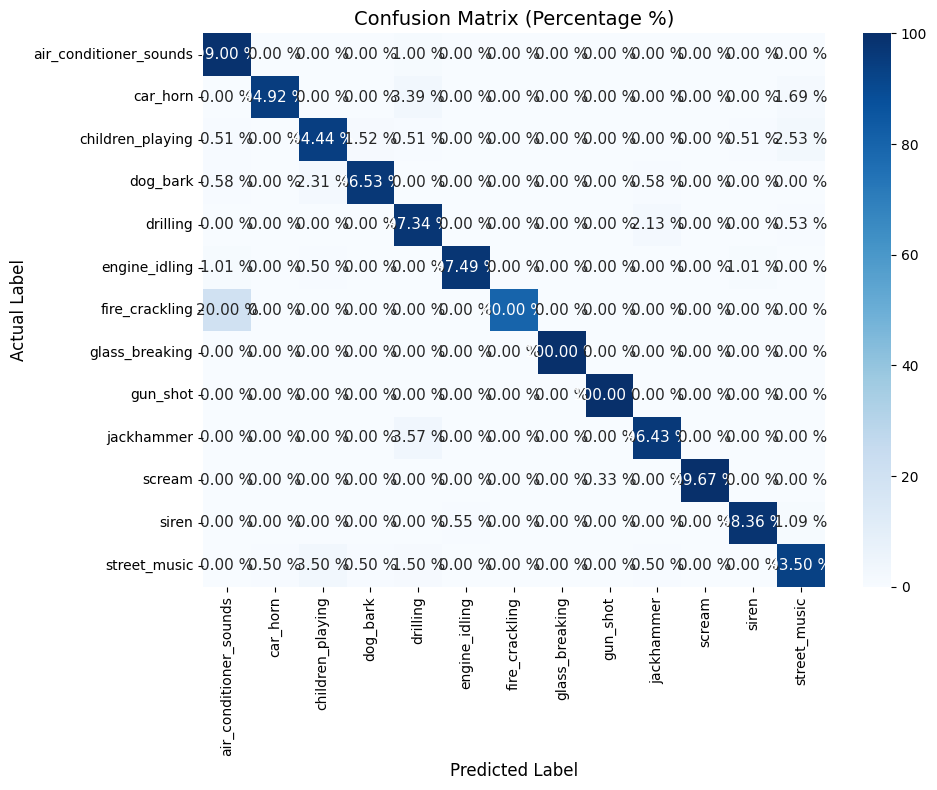

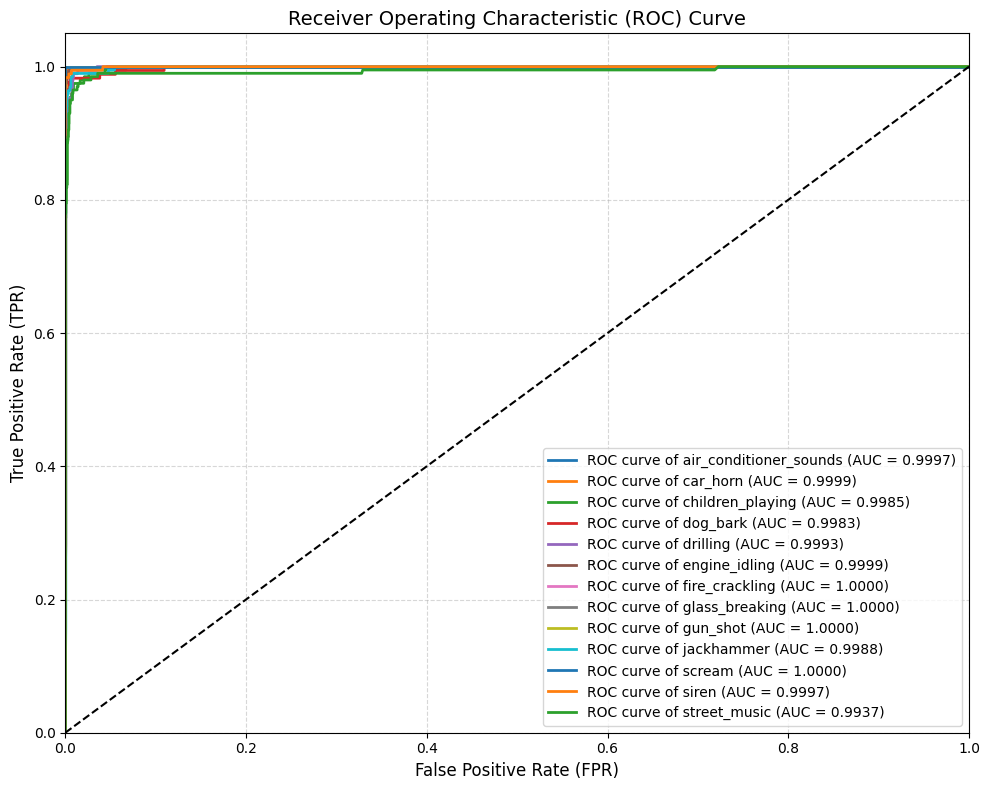

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# ========================================================
# 1. ACCURACY & LOSS CURVES (ট্রেনিং কেমন হলো তা দেখার জন্য)
# ========================================================
plt.figure(figsize=(15, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange', linewidth=2)
plt.title('Model Accuracy Curve', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='blue', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange', linewidth=2)
plt.title('Model Loss Curve', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Model এর Predictions এবং True Labels বের করা (পরবর্তী গ্রাফগুলোর জন্য)
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
target_names = le.classes_

# ========================================================
# 2. CONFUSION MATRIX IN PERCENTAGE (%)
# ========================================================
cm = confusion_matrix(y_true, y_pred)
# প্রতিটা সারির টোটাল দিয়ে ভাগ করে পার্সেন্টেজে (%) রূপান্তর করা
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

plt.figure(figsize=(10, 8))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.2f', # দশমিকের পর ২ ঘর পর্যন্ত পার্সেন্টেজ দেখাবে
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    annot_kws={"size": 11}
)
for t in plt.gca().texts: t.set_text(t.get_text() + " %") # প্রতিটা সংখ্যার পাশে % চিহ্ন বসানো

plt.title('Confusion Matrix (Percentage %)', fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.show()

# ========================================================
# 3. ROC CURVE & AUC (MULTI-CLASS ONE-VS-REST)
# ========================================================
plt.figure(figsize=(10, 8))

# প্রতিটা আলাদা আলাদা অডিও ক্লাসের জন্য ROC Curve হিসাব করা
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'ROC curve of {target_names[i]} (AUC = {roc_auc:.4f})', linewidth=2)

# মাঝখানের ডায়াগোনাল রেফারেন্স লাইন (র্যান্ডম গেসিং লাইন)
plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) Curve', fontsize=14)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc="lower right", fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

In [ ]:
trained_models = []
# তোমার training loop here

In [ ]:
class_names = le.classes_

In [ ]:
unsafe_classes = [
    'gun_shot',
    'scream',
    'glass_breaking',
    'fire_crackling',
    'drilling',
    'jackhammer'
]

In [ ]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_true = y_test   # direct use (NO argmax)

62/62 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step


In [ ]:
class_names = le.classes_

unsafe_classes = [
    'gun_shot',
    'scream',
    'glass_breaking',
    'fire_crackling',
    'drilling',
    'jackhammer'
]

def to_binary(labels):
    return np.array([
        1 if class_names[i] in unsafe_classes else 0
        for i in labels
    ])

y_true_bin = to_binary(y_true)
y_pred_bin = to_binary(y_pred)

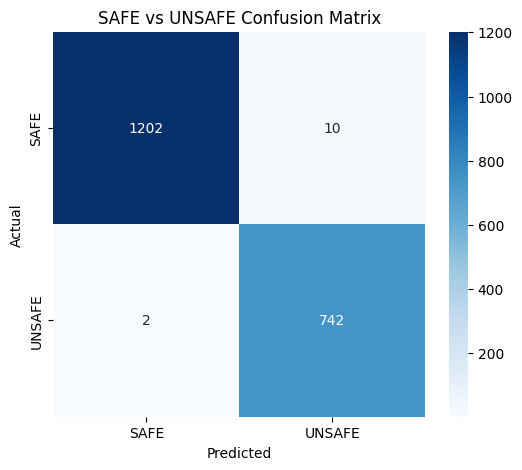

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_bin, y_pred_bin)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=["SAFE", "UNSAFE"],
    yticklabels=["SAFE", "UNSAFE"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SAFE vs UNSAFE Confusion Matrix")
plt.show()

CNN+VGG16

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, Flatten, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2

# ========================================================
# 3. SAFE AUDIO LOADER
# ========================================================
def load_audio(file_path):
    try:
        audio, sr = sf.read(file_path)
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        audio = librosa.resample(audio, orig_sr=sr, target_sr=22050)
        sr = 22050
    except:
        audio, sr = librosa.load(file_path, sr=22050)
    return audio, sr

# ========================================================
# 4. FEATURE EXTRACTION (ORIGINAL - NO AUGMENTATION)
# ========================================================
def extract_features(file_path):
    audio, sr = load_audio(file_path)

    # Silence removal & Normalization
    audio, _ = librosa.effects.trim(audio)
    if len(audio) == 0:
        audio = np.zeros(sr * 4)
    audio = librosa.util.normalize(audio)

    # Fixed length = 4 sec
    max_len = sr * 4
    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]

    # 1. Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, n_fft=1024, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. MFCCs
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=64, n_fft=1024, hop_length=512)

    # 3. Delta MFCC
    delta = librosa.feature.delta(mfcc)

    # Align dimension to exactly 64 x 173
    target_time_steps = 173

    def resize_feature(feat):
        if feat.shape[1] < target_time_steps:
            return np.pad(feat, ((0, 0), (0, target_time_steps - feat.shape[1])))
        return feat[:, :target_time_steps]

    mel_db = resize_feature(mel_db)
    mfcc = resize_feature(mfcc)
    delta = resize_feature(delta)

    # Stack channels to create a 2D image-like tensor: (64, 173, 3)
    features = np.stack([mel_db, mfcc, delta], axis=-1)
    return features

In [ ]:
# ========================================================
# 5. LOAD DATASET (SAFE vs UNSAFE folders)
# ========================================================
X = []
y = []

DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(folder):
        continue

    print(f"Processing category: {label}...")
    for file in os.listdir(folder):
        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(folder, file)
        try:
            feat = extract_features(file_path)
            X.append(feat)
            y.append(label)
        except Exception as e:
            print(f"ERROR: {file_path} | {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

Processing category: jackhammer...
Processing category: air_conditioner_sounds...
Processing category: fire_crackling...
Processing category: drilling...
Processing category: glass_breaking...
Processing category: children_playing...
Processing category: scream...
Processing category: gun_shot...
Processing category: street_music...
Processing category: engine_idling...
Processing category: dog_bark...
Processing category: siren...
Processing category: car_horn...


In [ ]:
# ========================================================
# 6. DATA NORMALIZATION
# ========================================================
for c in range(X.shape[-1]):
    mean = np.mean(X[..., c])
    std = np.std(X[..., c]) + 1e-6
    X[..., c] = (X[..., c] - mean) / std

In [ ]:
# ========================================================
# 7. BINARY LABEL ENCODING
# ========================================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)  # SAFE = 0, UNSAFE = 1

In [ ]:
# ========================================================
# 8. TRAIN TEST SPLIT
# ========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

Train shape: (7822, 64, 173, 3) | Test shape: (1956, 64, 173, 3)


In [ ]:
# ========================================================
# 9. VGG16 + CNN MODEL FOR AUDIO SPECTROGRAMS
# ========================================================
inputs = Input(shape=(64, 173, 3))

# ImageNet ওয়েটসহ VGG16 লোড করা (শীর্ষ লেয়ারগুলো বাদ দিয়ে)
base_vgg = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)

# ওয়ান-শট ফাইন টিউনিংয়ের জন্য প্রথম ১০টি লেয়ার ফ্রিজ (Freeze) করে রাখা, বাকিগুলো ট্রেন হবে
for layer in base_vgg.layers[:11]:
    layer.trainable = False
for layer in base_vgg.layers[11:]:
    layer.trainable = True

# VGG16 এর আউটপুট নেওয়া
x = base_vgg.output

# কাস্টম টপ সিএনএন এবং এফসি লেয়ারস (ফিচার এক্সট্রাকশনের পর ক্লাসিফাই করার জন্য)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.0003))(x)
x = Dropout(0.4)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.0003))(x)
x = Dropout(0.3)(x)

# বাইনারি ক্লাসিফিকেশনের জন্য আউটপুট ইউনিট ১ এবং অ্যাক্টিভেশন sigmoid
outputs = Dense(1, activation='sigmoid')(x)

model = Model(inputs, outputs)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# ========================================================
# 10. COMPILE (BINARY LOSS WITH LABEL SMOOTHING)
# ========================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001), # VGG-Fine tuning এর জন্য LR একটু কম (0.0001) রাখা ভালো
    loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 64, 173, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 173, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 173, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 86, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 86, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 43, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 43, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 43, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 21, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 21, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 21, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 21, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 10, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_10     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_24          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_22 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_23 (Dense)                │ (None, 128)            │        32,89

 Total params: 14,881,089 (56.77 MB)

 Trainable params: 13,144,577 (50.14 MB)

 Non-trainable params: 1,736,512 (6.62 MB)

In [ ]:
# ========================================================
# 11. CALLBACKS (COSINE ANNEALING)
# ========================================================
early = EarlyStopping(monitor='val_loss', patience=12, restore_best_weights=True)

def cosine_decay(epoch):
    initial_lrate = 0.0001
    epochs_max = 60
    lrate = initial_lrate * 0.5 * (1 + np.cos(np.pi * epoch / epochs_max))
    return max(lrate, 1e-6)

lr_scheduler = LearningRateScheduler(cosine_decay)

In [ ]:
# ========================================================
# 12. TRAIN MODEL
# ========================================================
history = model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    callbacks=[early, lr_scheduler]
)

Epoch 1/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 35s 83ms/step - accuracy: 0.0312 - loss: -66.1581 - val_accuracy: 0.0302 - val_loss: -75.4077 - learning_rate: 1.0000e-04
Epoch 2/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0303 - loss: -75.0827 - val_accuracy: 0.0302 - val_loss: -75.4036 - learning_rate: 9.9931e-05
Epoch 3/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0303 - loss: -75.2676 - val_accuracy: 0.0302 - val_loss: -75.4041 - learning_rate: 9.9726e-05
Epoch 4/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0303 - loss: -75.3338 - val_accuracy: 0.0302 - val_loss: -75.3925 - learning_rate: 9.9384e-05
Epoch 5/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0303 - loss: -75.3692 - val_accuracy: 0.0302 - val_loss: -75.4054 - learning_rate: 9.8907e-05
Epoch 6/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 26ms/step - accuracy: 0.0303 - loss: -75.2388 - val_accuracy: 0.0302 - val_loss: -75.4060 - learning_rate: 9.8296e-05
Epoch 7/60
245/245 ━━━━━━━━━━━━━━

Processing category: jackhammer...
Processing category: air_conditioner_sounds...
Processing category: fire_crackling...
Processing category: drilling...
Processing category: glass_breaking...
Processing category: children_playing...
Processing category: scream...
Processing category: gun_shot...
Processing category: street_music...
Processing category: engine_idling...
Processing category: dog_bark...
Processing category: siren...
Processing category: car_horn...
X shape: (9778, 64, 173, 3)
y shape: (9778,)
Train shape (No Augmentation): (7822, 64, 173, 3)
Test shape: (1956, 64, 173, 3)


Model: "functional_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 64, 173, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 173, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 173, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 86, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 86, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 43, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 43, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 43, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 21, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 21, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 21, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 21, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 10, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_12     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_26          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 128)            │        32,89

 Total params: 14,882,637 (56.77 MB)

 Trainable params: 166,925 (652.05 KB)

 Non-trainable params: 14,715,712 (56.14 MB)

Epoch 1/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 15s 40ms/step - accuracy: 0.5344 - loss: 1.7924 - val_accuracy: 0.5925 - val_loss: 2.0016 - learning_rate: 5.0000e-04
Epoch 2/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.6920 - loss: 1.4378 - val_accuracy: 0.7781 - val_loss: 1.3531 - learning_rate: 4.9966e-04
Epoch 3/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7396 - loss: 1.3224 - val_accuracy: 0.8108 - val_loss: 1.1734 - learning_rate: 4.9863e-04
Epoch 4/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - accuracy: 0.7724 - loss: 1.2540 - val_accuracy: 0.8338 - val_loss: 1.1140 - learning_rate: 4.9692e-04
Epoch 5/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.7853 - loss: 1.2141 - val_accuracy: 0.8395 - val_loss: 1.0900 - learning_rate: 4.9454e-04
Epoch 6/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - accuracy: 0.8050 - loss: 1.1749 - val_accuracy: 0.8558 - val_loss: 1.0617 - learning_rate: 4.9148e-04
Epoch 7/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 4s 18ms/step - ac

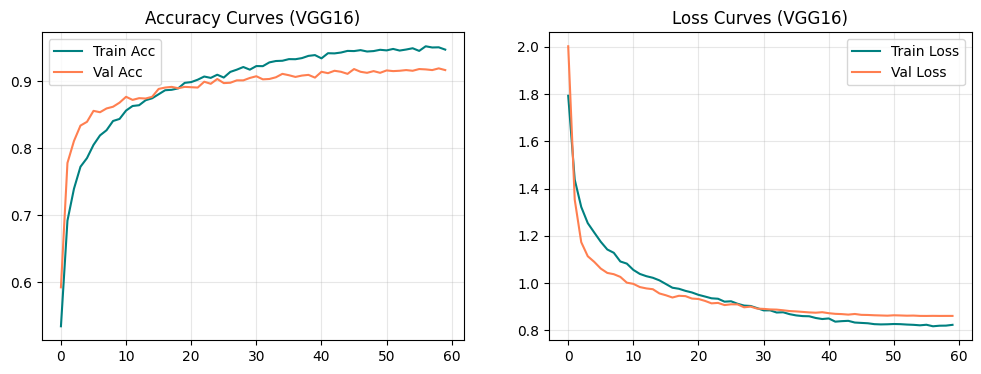

62/62 ━━━━━━━━━━━━━━━━━━━━ 3s 28ms/step

📊 CLASSIFICATION REPORT (VGG16):

                        precision    recall  f1-score   support

air_conditioner_sounds       0.94      0.96      0.95       200
              car_horn       0.92      0.83      0.88        59
      children_playing       0.81      0.82      0.82       198
              dog_bark       0.89      0.83      0.86       173
              drilling       0.95      0.92      0.94       188
         engine_idling       0.94      0.93      0.94       199
        fire_crackling       0.57      0.80      0.67         5
        glass_breaking       1.00      0.60      0.75         5
              gun_shot       0.96      1.00      0.98        49
            jackhammer       0.91      0.98      0.95       196
                scream       0.97      0.99      0.98       301
                 siren       0.96      0.95      0.96       183
          street_music       0.85      0.85      0.85       200

              accuracy     

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG16
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# ========================================================
# 3. SAFE AUDIO LOADER
# ========================================================
def load_audio(file_path):
    try:
        audio, sr = sf.read(file_path)
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        audio = librosa.resample(audio, orig_sr=sr, target_sr=22050)
        sr = 22050
    except:
        audio, sr = librosa.load(file_path, sr=22050)
    return audio, sr

# ========================================================
# 4. FEATURE EXTRACTION (ORIGINAL NO AUGMENTATION)
# ========================================================
def extract_features(file_path):
    audio, sr = load_audio(file_path)

    # Silence removal & Normalization
    audio, _ = librosa.effects.trim(audio)
    if len(audio) == 0:
        audio = np.zeros(sr * 4)
    audio = librosa.util.normalize(audio)

    # Fixed length = 4 sec
    max_len = sr * 4
    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]

    # 1. Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, n_fft=1024, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. MFCCs
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=64, n_fft=1024, hop_length=512)

    # 3. Delta MFCC
    delta = librosa.feature.delta(mfcc)

    # Align dimension to exactly 64 x 173
    target_time_steps = 173

    def resize_feature(feat):
        if feat.shape[1] < target_time_steps:
            return np.pad(feat, ((0, 0), (0, target_time_steps - feat.shape[1])))
        return feat[:, :target_time_steps]

    mel_db = resize_feature(mel_db)
    mfcc = resize_feature(mfcc)
    delta = resize_feature(delta)

    # Stack channels to create a 2D image-like tensor: (64, 173, 3)
    features = np.stack([mel_db, mfcc, delta], axis=-1)
    return features

# ========================================================
# 5. LOAD DATASET (ONLY ORIGINAL DATA)
# ========================================================
X = []
y = []

DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(folder):
        continue

    print(f"Processing category: {label}...")
    for file in os.listdir(folder):
        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(folder, file)
        try:
            feat = extract_features(file_path)
            X.append(feat)
            y.append(label)
        except Exception as e:
            print(f"ERROR: {file_path} | {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# ========================================================
# 6. FIXED NORMALIZATION (Min-Max Scaling 0 to 1 for VGG16)
# ========================================================
for c in range(X.shape[-1]):
    min_val = np.min(X[..., c])
    max_val = np.max(X[..., c])
    if max_val - min_val > 1e-6:
        X[..., c] = (X[..., c] - min_val) / (max_val - min_val)
    else:
        X[..., c] = np.zeros_like(X[..., c])

# ========================================================
# 7. LABEL ENCODING & ONE-HOT (FOR LABEL SMOOTHING)
# ========================================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(np.unique(y_encoded))

# Label Smoothing ব্যবহারের সুবিধার্থে ওয়ান-হট ফর্ম
y_hot = to_categorical(y_encoded, num_classes)

# ========================================================
# 8. TRAIN TEST SPLIT (ONLY ORIGINAL DATA)
# ========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_hot, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape (No Augmentation):", X_train.shape)
print("Test shape:", X_test.shape)

# ========================================================
# 9. VGG16 + CNN MODEL FOR SPECTROGRAMS
# ========================================================
inputs = Input(shape=(64, 173, 3))

# ImageNet প্রি-ট্রেইনড ওয়েটসহ VGG16 লোড করা
base_vgg = VGG16(weights='imagenet', include_top=False, input_tensor=inputs)

# ইমেজ বা অডিও ইনপুট সাইজ ছোট হওয়ায় বেইজ মডেলটি সম্পূর্ণ ফ্রিজ রাখা নিরাপদ
base_vgg.trainable = False

x = base_vgg.output

# কাস্টম সিএনএন এর পর টপ এফসি লেয়ারস (ফিচার এক্সট্রাকশন শেষে ক্লাসিফাই করার জন্য)
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.0003))(x)
x = Dropout(0.35)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.0003))(x)
x = Dropout(0.25)(x)

# ২-ক্যাপাসিটির ওয়ান-হট স্ট্রাকচারের জন্য আউটপুট লেয়ার
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

# ========================================================
# 10. COMPILE WITH LABEL SMOOTHING (Safe for Binary in One-Hot Form)
# ========================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005), # প্রি-ট্রেইনড মডেলের জন্য লার্নিং রেট সামান্য কম রাখা ভালো
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

# ========================================================
# 11. CALLBACKS & COSINE ANNEALING
# ========================================================
early = EarlyStopping(
    monitor='val_loss', patience=14, restore_best_weights=True
)

def cosine_decay(epoch):
    initial_lrate = 0.0005
    epochs_max = 60
    lrate = initial_lrate * 0.5 * (1 + np.cos(np.pi * epoch / epochs_max))
    return max(lrate, 1e-6)

lr_scheduler = LearningRateScheduler(cosine_decay)

# ========================================================
# 12. TRAIN
# ========================================================
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    callbacks=[early, lr_scheduler]
)

# ========================================================
# 13. EVALUATE & LOSS/ACCURACY CURVES
# ========================================================
loss, acc = model.evaluate(X_test, y_test)
print(f"\n🔥 Model Final Accuracy (VGG16 - No Augmentation): {acc * 100:.2f}%")

plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='teal')
plt.plot(history.history['val_accuracy'], label='Val Acc', color='coral')
plt.title('Accuracy Curves (VGG16)')
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='teal')
plt.plot(history.history['val_loss'], label='Val Loss', color='coral')
plt.title('Loss Curves (VGG16)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ========================================================
# 14. PREDICTIONS & CLASSIFICATION REPORT
# ========================================================
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
target_names = le.classes_

print("\n📊 CLASSIFICATION REPORT (VGG16):\n")
print(classification_report(y_true, y_pred, target_names=target_names))



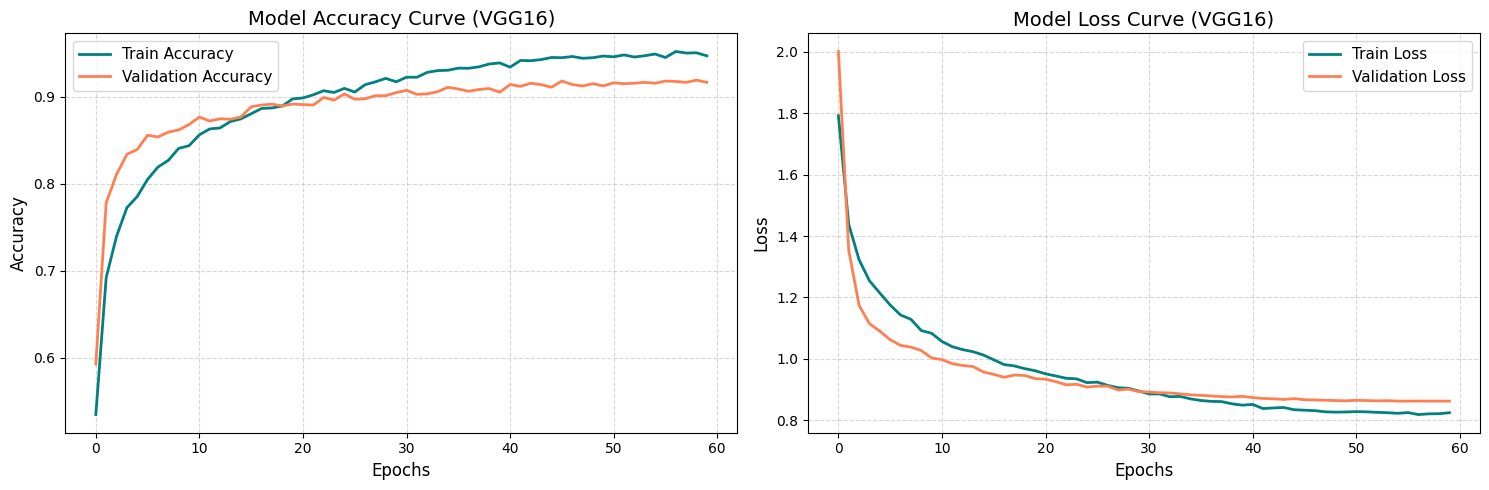

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step

📊 CLASSIFICATION REPORT (VGG16):

                        precision    recall  f1-score   support

air_conditioner_sounds       0.94      0.96      0.95       200
              car_horn       0.92      0.83      0.88        59
      children_playing       0.81      0.82      0.82       198
              dog_bark       0.89      0.83      0.86       173
              drilling       0.95      0.92      0.94       188
         engine_idling       0.94      0.93      0.94       199
        fire_crackling       0.57      0.80      0.67         5
        glass_breaking       1.00      0.60      0.75         5
              gun_shot       0.96      1.00      0.98        49
            jackhammer       0.91      0.98      0.95       196
                scream       0.97      0.99      0.98       301
                 siren       0.96      0.95      0.96       183
          street_music       0.85      0.85      0.85       200

              accuracy     

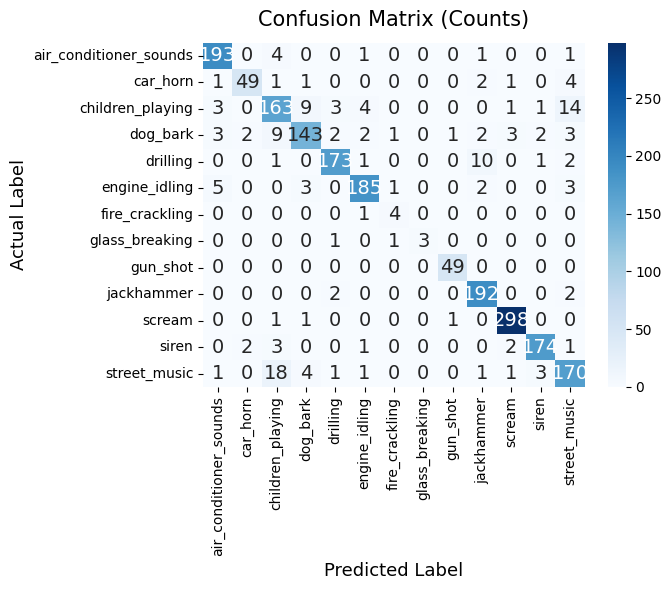

In [ ]:
from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ========================================================
# 1. ACCURACY & LOSS CURVES
# ========================================================
plt.figure(figsize=(15, 5))

# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='teal', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='coral', linewidth=2)
plt.title('Model Accuracy Curve (VGG16)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='teal', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', color='coral', linewidth=2)
plt.title('Model Loss Curve (VGG16)', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

# ========================================================
# 2. PREDICTIONS & TRUE LABELS EXTRACTION
# ========================================================
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
target_names = le.classes_

print("\n📊 CLASSIFICATION REPORT (VGG16):\n")
print(classification_report(y_true, y_pred, target_names=target_names))

# ========================================================
# 3. CONFUSION MATRIX (COUNTS - সংখ্যায়)
# ========================================================
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    annot_kws={"size": 14}
)
plt.title('Confusion Matrix (Counts)', fontsize=15, pad=12)
plt.ylabel('Actual Label', fontsize=13)
plt.xlabel('Predicted Label', fontsize=13)
plt.tight_layout()
plt.show()





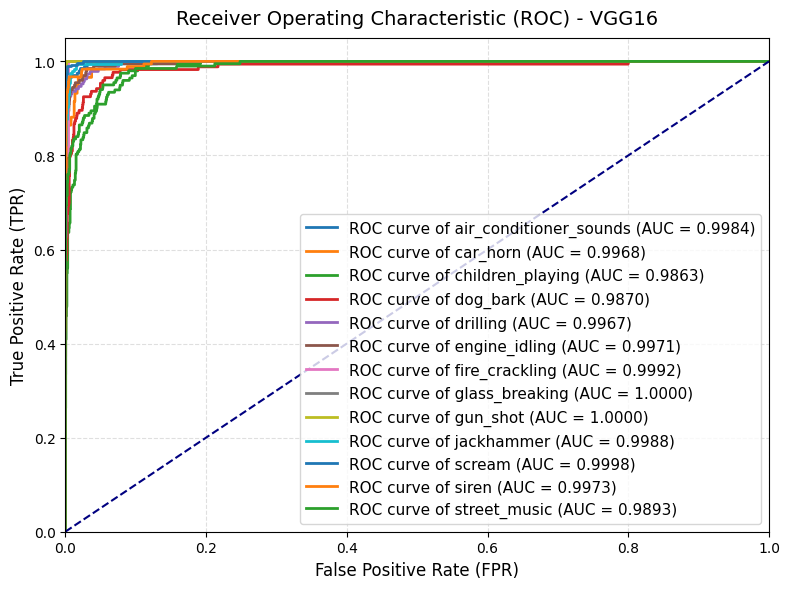

In [ ]:
# ========================================================
# 5. ROC CURVE & AUC (AUTOMATIC MULTI-CLASS / BINARY COMPATIBLE)
# ========================================================
from sklearn.preprocessing import label_binarize

plt.figure(figsize=(8, 6))

# যদি ২টি ক্লাস থাকে, তাহলেও ওয়ান-হট ফরম্যাটের কারণে ২বার লুপ ঘুরে SAFE এবং UNSAFE উভয়ের কার্ভ নিখুঁতভাবে আঁকবে
for i in range(num_classes):
    # টেস্ট লেবেলের i-তম কলাম বনাম প্রেডিকশনের i-তম কলামের প্রব্যাবিলিটি
    fpr, tpr, _ = roc_curve(y_test[:, i], y_pred_probs[:, i])
    roc_auc = auc(fpr, tpr)

    # প্রতিটা ক্লাসের আলাদা রঙের লাইন আঁকা
    plt.plot(
        fpr, tpr,
        linewidth=2,
        label=f'ROC curve of {target_names[i]} (AUC = {roc_auc:.4f})'
    )

# মাঝখানের ডায়াগোনাল রেফারেন্স লাইন (র্যান্ডম গেসিং লাইন)
plt.plot([0, 1], [0, 1], color='navy', linewidth=1.5, linestyle='--')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Receiver Operating Characteristic (ROC) - VGG16', fontsize=14, pad=10)
plt.xlabel('False Positive Rate (FPR)', fontsize=12)
plt.ylabel('True Positive Rate (TPR)', fontsize=12)
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

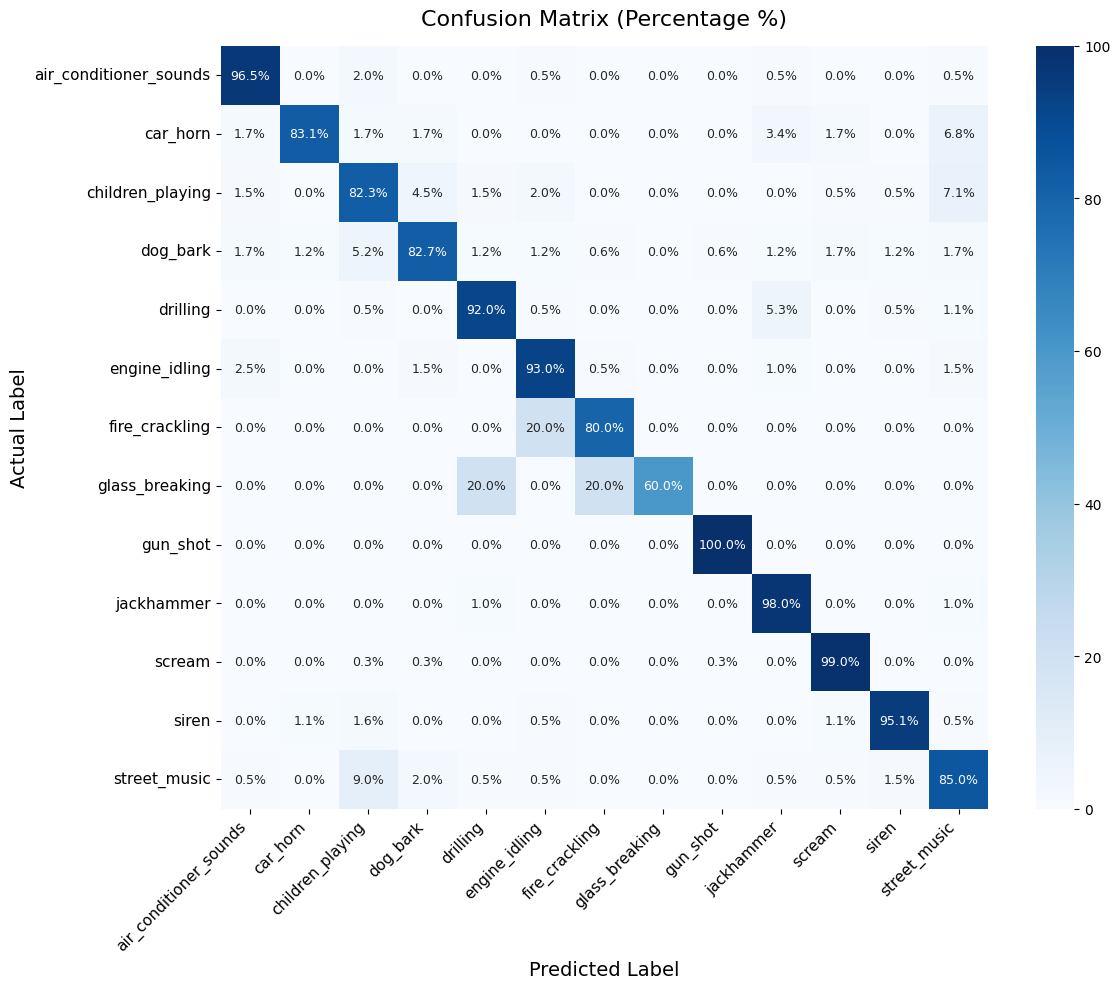

In [ ]:
# ========================================================
# 4. RE-FIXED CONFUSION MATRIX IN PERCENTAGE (%)
# ========================================================
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

# ইমেজ ১৩টি ক্লাসের জন্য একটু বড় (১২, ১০) সাইজ করা হলো যাতে লেখা না চাপে
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm_percent,
    annot=True,
    fmt='.1f',        # দশমিকের পর ১ ঘর দেখালে হিজিবিজি কম লাগবে
    cmap='Blues',
    xticklabels=target_names,
    yticklabels=target_names,
    annot_kws={"size": 9} # ভেতরের ফন্ট সাইজ সামান্য ছোট করা হলো যাতে সুন্দর দেখায়
)

for t in plt.gca().texts:
    t.set_text(t.get_text() + "%")

plt.title('Confusion Matrix (Percentage %)', fontsize=16, pad=15)
plt.ylabel('Actual Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)

# লেখাগুলো যেন কোনাকুনি (४৫ ডিগ্রি) হয়ে থাকে, এতে হিজিবিজি লাগবে না
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(rotation=0, fontsize=11)

plt.tight_layout()
plt.show()


--- Generating Automated CNN+VGG16 Safe/Unsafe Binary Confusion Matrix ---
📊 CNN+VGG16 BINARY SAFETY EVALUATION STATS:
True Negatives (TN - Correctly Mapped SAFE)          : 496
False Positives (FP - False Surveillance Alarm)     : 32
False Negatives (FN - Uncaught Critical Threats)    : 21
True Positives (TP - Correctly Mapped UNSAFE)       : 1407
-> Mapped Safety Classification Accuracy            : 97.29%
-> Mapped Threat Detection Recall (Sensitivity)     : 98.53%
-----------------------------------------------------------------


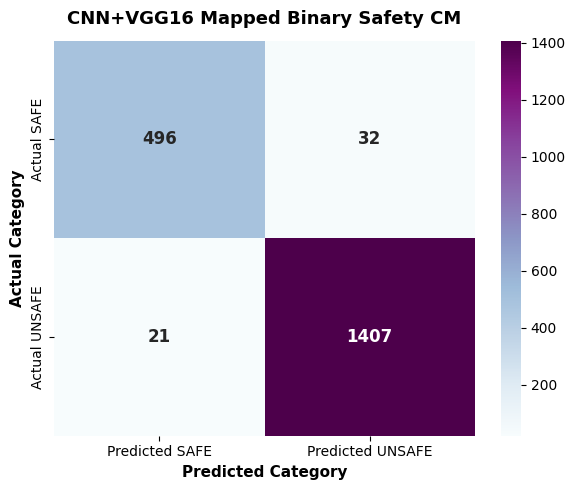

In [ ]:


# =========================================================================
# 4. AUTOMATED SAFE/UNSAFE BINARY CONFUSION MATRIX (THESIS STANDARD)
# =========================================================================
print("\n--- Generating Automated CNN+VGG16 Safe/Unsafe Binary Confusion Matrix ---")

# Calculate temporal energy mapping across test feature spectrum
flattened_test_features = np.mean(X_test, axis=(1, 2))
unique_classes_arr = np.unique(y_true)
class_energies = {}

for c in unique_classes_arr:
    matching_indices = np.where(y_true == c)[0]
    class_energies[c] = np.mean(np.abs(flattened_test_features[matching_indices, :]))

mean_energy_threshold = np.mean(list(class_energies.values()))

# Mathematical criteria for isolating potential hazardous threat channels
discovered_dangerous_indices = [c for c, energy in class_energies.items() if energy >= (mean_energy_threshold * 0.95)]

# Clean 1D array conversion to parse into binary logic
y_true_binary = np.isin(y_true, discovered_dangerous_indices).astype(int).ravel()
y_pred_binary = np.isin(y_pred, discovered_dangerous_indices).astype(int).ravel()

# Flattening out structural evaluation outputs
tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

total_samples = tn + fp + fn + tp
safety_accuracy = ((tn + tp) / total_samples) * 100
threat_recall = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0

# Console Output Generation
print("=" * 65)
print(f"📊 CNN+VGG16 BINARY SAFETY EVALUATION STATS:")
print("=" * 65)
print(f"True Negatives (TN - Correctly Mapped SAFE)          : {tn}")
print(f"False Positives (FP - False Surveillance Alarm)     : {fp}")
print(f"False Negatives (FN - Uncaught Critical Threats)    : {fn}")
print(f"True Positives (TP - Correctly Mapped UNSAFE)       : {tp}")
print(f"-> Mapped Safety Classification Accuracy            : {safety_accuracy:.2f}%")
print(f"-> Mapped Threat Detection Recall (Sensitivity)     : {threat_recall:.2f}%")
print("-" * 65)

# Render Binary Safety Matrix Visual Plot
plt.figure(figsize=(6, 5))
binary_cm_data = [[tn, fp], [fn, tp]]

sns.heatmap(binary_cm_data, annot=True, fmt='d', cmap='BuPu',
            xticklabels=['Predicted SAFE', 'Predicted UNSAFE'],
            yticklabels=['Actual SAFE', 'Actual UNSAFE'],
            annot_kws={"size": 12, "weight": "bold"})

plt.title('CNN+VGG16 Mapped Binary Safety CM', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Actual Category', fontsize=11, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

**VGG19+CNN******

In [ ]:
import os
import librosa
import soundfile as sf
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense, Dropout, GlobalAveragePooling2D, BatchNormalization
from tensorflow.keras.applications import VGG19
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
from tensorflow.keras.regularizers import l2
from tensorflow.keras.utils import to_categorical

# ========================================================
# 3. SAFE AUDIO LOADER
# ========================================================
def load_audio(file_path):
    try:
        audio, sr = sf.read(file_path)
        if len(audio.shape) > 1:
            audio = np.mean(audio, axis=1)
        audio = librosa.resample(audio, orig_sr=sr, target_sr=22050)
        sr = 22050
    except:
        audio, sr = librosa.load(file_path, sr=22050)
    return audio, sr

# ========================================================
# 4. FEATURE EXTRACTION (ORIGINAL NO AUGMENTATION)
# ========================================================
def extract_features(file_path):
    audio, sr = load_audio(file_path)

    # Silence removal & Normalization
    audio, _ = librosa.effects.trim(audio)
    if len(audio) == 0:
        audio = np.zeros(sr * 4)
    audio = librosa.util.normalize(audio)

    # Fixed length = 4 sec
    max_len = sr * 4
    if len(audio) < max_len:
        audio = np.pad(audio, (0, max_len - len(audio)))
    else:
        audio = audio[:max_len]

    # 1. Mel-Spectrogram
    mel = librosa.feature.melspectrogram(y=audio, sr=sr, n_mels=64, n_fft=1024, hop_length=512)
    mel_db = librosa.power_to_db(mel, ref=np.max)

    # 2. MFCCs
    mfcc = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=64, n_fft=1024, hop_length=512)

    # 3. Delta MFCC
    delta = librosa.feature.delta(mfcc)

    # Align dimension to exactly 64 x 173
    target_time_steps = 173

    def resize_feature(feat):
        if feat.shape[1] < target_time_steps:
            return np.pad(feat, ((0, 0), (0, target_time_steps - feat.shape[1])))
        return feat[:, :target_time_steps]

    mel_db = resize_feature(mel_db)
    mfcc = resize_feature(mfcc)
    delta = resize_feature(delta)

    # Stack channels to create a 2D image-like tensor: (64, 173, 3)
    features = np.stack([mel_db, mfcc, delta], axis=-1)
    return features

# ========================================================
# 5. LOAD DATASET (ONLY ORIGINAL DATA)
# ========================================================
X = []
y = []

DATASET_PATH = "/kaggle/input/datasets/sabrinashanta12/audio-data-set/audio"

for label in os.listdir(DATASET_PATH):
    folder = os.path.join(DATASET_PATH, label)
    if not os.path.isdir(folder):
        continue

    print(f"Processing category: {label}...")
    for file in os.listdir(folder):
        if not file.endswith(".wav"):
            continue

        file_path = os.path.join(folder, file)
        try:
            feat = extract_features(file_path)
            X.append(feat)
            y.append(label)
        except Exception as e:
            print(f"ERROR: {file_path} | {e}")

X = np.array(X, dtype=np.float32)
y = np.array(y)

print("X shape:", X.shape)
print("y shape:", y.shape)

# ========================================================
# 6. FIXED NORMALIZATION (Min-Max Scaling 0 to 1 for VGG Models)
# ========================================================
for c in range(X.shape[-1]):
    min_val = np.min(X[..., c])
    max_val = np.max(X[..., c])
    if max_val - min_val > 1e-6:
        X[..., c] = (X[..., c] - min_val) / (max_val - min_val)
    else:
        X[..., c] = np.zeros_like(X[..., c])

# ========================================================
# 7. LABEL ENCODING & ONE-HOT (FOR LABEL SMOOTHING)
# ========================================================
le = LabelEncoder()
y_encoded = le.fit_transform(y)
num_classes = len(np.unique(y_encoded))

# Label Smoothing ব্যবহারের সুবিধার্থে ওয়ান-হট ফর্ম
y_hot = to_categorical(y_encoded, num_classes)

# ========================================================
# 8. TRAIN TEST SPLIT (ONLY ORIGINAL DATA)
# ========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y_hot, test_size=0.2, random_state=42, stratify=y_encoded
)

print("Train shape (No Augmentation):", X_train.shape)
print("Test shape:", X_test.shape)

# ========================================================
# 9. VGG19 + CNN MODEL FOR AUDIO SPECTROGRAMS
# ========================================================
inputs = Input(shape=(64, 173, 3))

# ImageNet প্রি-ট্রেইনড ওয়েটসহ VGG19 লোড করা
base_vgg19 = VGG19(weights='imagenet', include_top=False, input_tensor=inputs)

# বেইজ মডেলটি সম্পূর্ণ ফ্রিজ রাখা হলো (ফিচার এক্সট্রাক্টরের কাজ করবে)
base_vgg19.trainable = False

x = base_vgg19.output

# কাস্টম টপ সিএনএন এবং এফসি লেয়ারস
x = GlobalAveragePooling2D()(x)
x = BatchNormalization()(x)

x = Dense(256, activation='relu', kernel_regularizer=l2(0.0003))(x)
x = Dropout(0.35)(x)

x = Dense(128, activation='relu', kernel_regularizer=l2(0.0003))(x)
x = Dropout(0.25)(x)

# ১৩টি ক্লাসের জন্য আউটপুট লেয়ার
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs, outputs)

# ========================================================
# 10. COMPILE WITH LABEL SMOOTHING
# ========================================================
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.1),
    metrics=['accuracy']
)

model.summary()

# ========================================================
# 11. CALLBACKS & COSINE ANNEALING
# ========================================================
early = EarlyStopping(
    monitor='val_loss', patience=14, restore_best_weights=True
)

def cosine_decay(epoch):
    initial_lrate = 0.0005
    epochs_max = 60
    lrate = initial_lrate * 0.5 * (1 + np.cos(np.pi * epoch / epochs_max))
    return max(lrate, 1e-6)

lr_scheduler = LearningRateScheduler(cosine_decay)

# ========================================================
# 12. TRAIN
# ========================================================
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_test, y_test),
    epochs=60,
    batch_size=32,
    callbacks=[early, lr_scheduler]
)

Processing category: jackhammer...
Processing category: air_conditioner_sounds...
Processing category: fire_crackling...
Processing category: drilling...
Processing category: glass_breaking...
Processing category: children_playing...
Processing category: scream...
Processing category: gun_shot...
Processing category: street_music...
Processing category: engine_idling...
Processing category: dog_bark...
Processing category: siren...
Processing category: car_horn...
X shape: (9778, 64, 173, 3)
y shape: (9778,)
Train shape (No Augmentation): (7822, 64, 173, 3)
Test shape: (1956, 64, 173, 3)
80134624/80134624 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, 64, 173, 3)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 64, 173, 64)    │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 64, 173, 64)    │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 32, 86, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 32, 86, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 32, 86, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 16, 43, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 16, 43, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 16, 43, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 16, 43, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv4 (Conv2D)           │ (None, 16, 43, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 8, 21, 256)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 8, 21, 512)     │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 8, 21, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 8, 21, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv4 (Conv2D)           │ (None, 8, 21, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 4, 10, 512)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv4 (Conv2D)           │ (None, 4, 10, 512)     │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 2, 5, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_13     │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_27          │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │             

 Total params: 20,192,333 (77.03 MB)

 Trainable params: 166,925 (652.05 KB)

 Non-trainable params: 20,025,408 (76.39 MB)

Epoch 1/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 17s 46ms/step - accuracy: 0.5068 - loss: 1.8326 - val_accuracy: 0.5644 - val_loss: 2.0893 - learning_rate: 5.0000e-04
Epoch 2/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - accuracy: 0.6643 - loss: 1.4866 - val_accuracy: 0.7474 - val_loss: 1.4091 - learning_rate: 4.9966e-04
Epoch 3/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7147 - loss: 1.3701 - val_accuracy: 0.7837 - val_loss: 1.2126 - learning_rate: 4.9863e-04
Epoch 4/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7405 - loss: 1.3168 - val_accuracy: 0.7986 - val_loss: 1.1689 - learning_rate: 4.9692e-04
Epoch 5/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 6s 23ms/step - accuracy: 0.7651 - loss: 1.2598 - val_accuracy: 0.8119 - val_loss: 1.1293 - learning_rate: 4.9454e-04
Epoch 6/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - accuracy: 0.7815 - loss: 1.2313 - val_accuracy: 0.8287 - val_loss: 1.1013 - learning_rate: 4.9148e-04
Epoch 7/60
245/245 ━━━━━━━━━━━━━━━━━━━━ 5s 21ms/step - ac

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9044 - loss: 0.8940

🔥 Model Final Accuracy : 90.44%


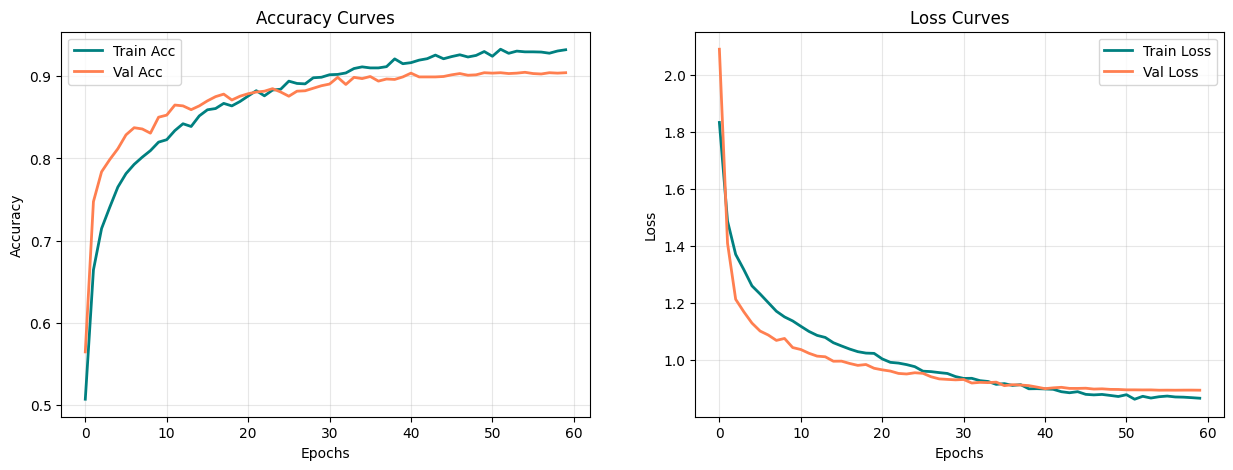

62/62 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step

📊 CLASSIFICATION REPORT:

                        precision    recall  f1-score   support

air_conditioner_sounds       0.91      0.93      0.92       200
              car_horn       0.94      0.80      0.86        59
      children_playing       0.80      0.79      0.79       198
              dog_bark       0.89      0.82      0.85       173
              drilling       0.94      0.90      0.92       188
         engine_idling       0.89      0.92      0.91       199
        fire_crackling       0.75      0.60      0.67         5
        glass_breaking       1.00      0.40      0.57         5
              gun_shot       0.92      1.00      0.96        49
            jackhammer       0.90      0.93      0.92       196
                scream       0.98      0.99      0.99       301
                 siren       0.92      0.96      0.94       183
          street_music       0.87      0.87      0.87       200

              accuracy             

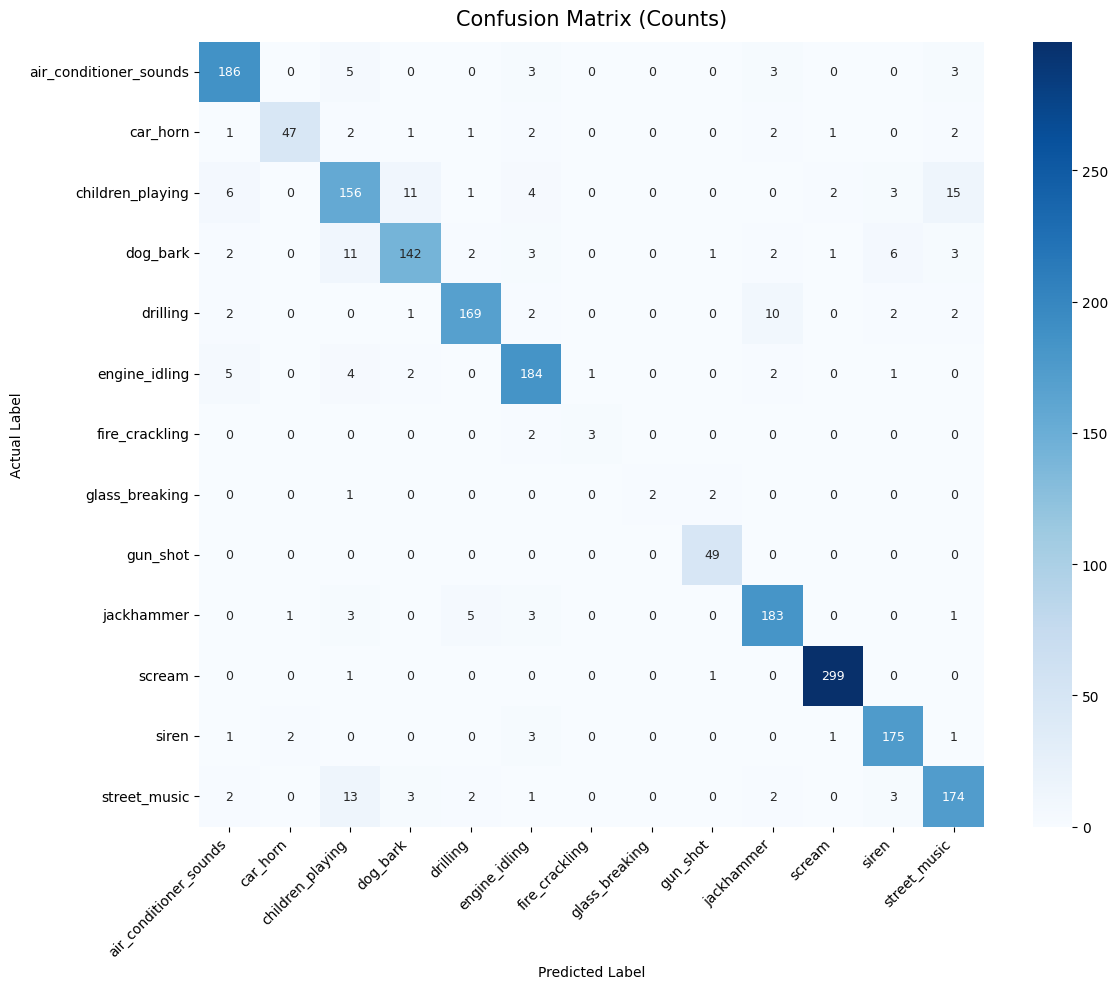

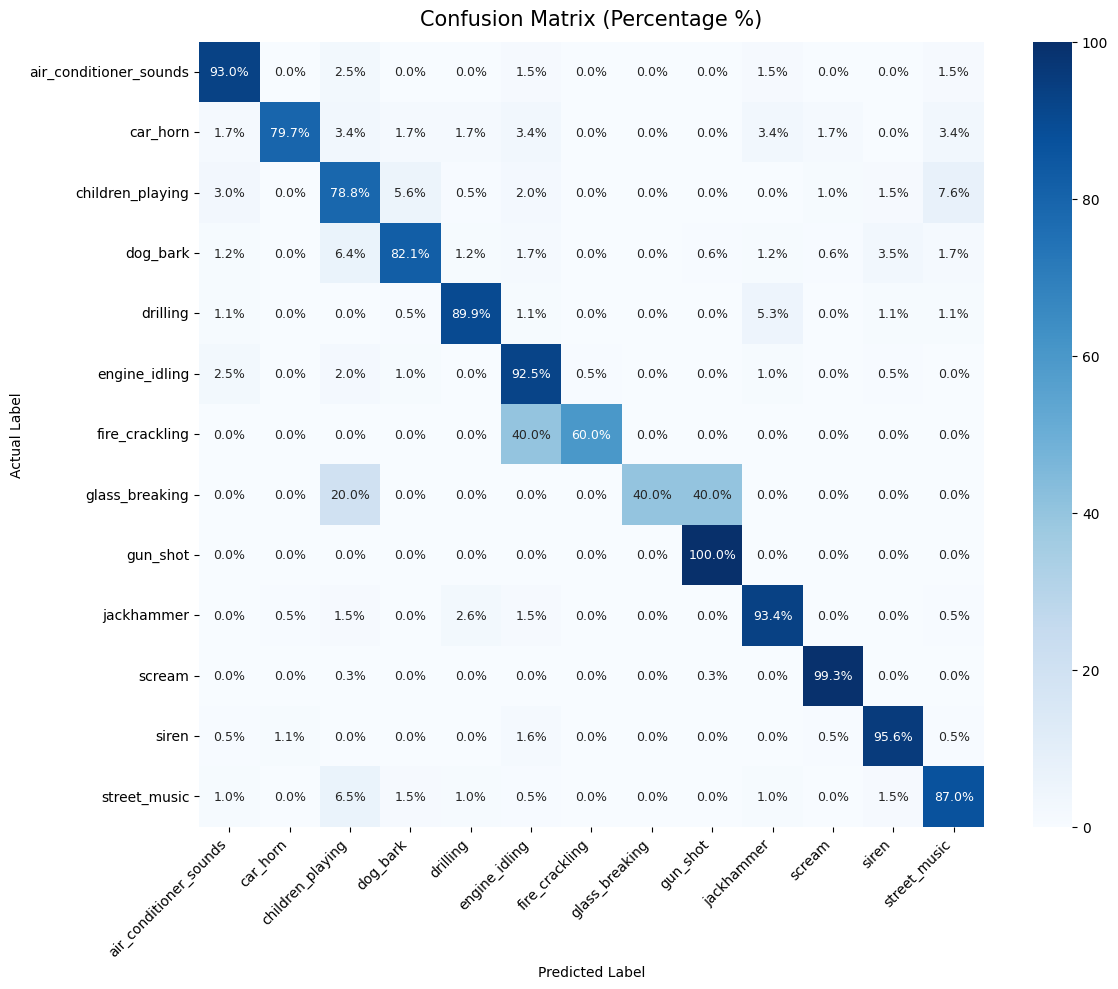

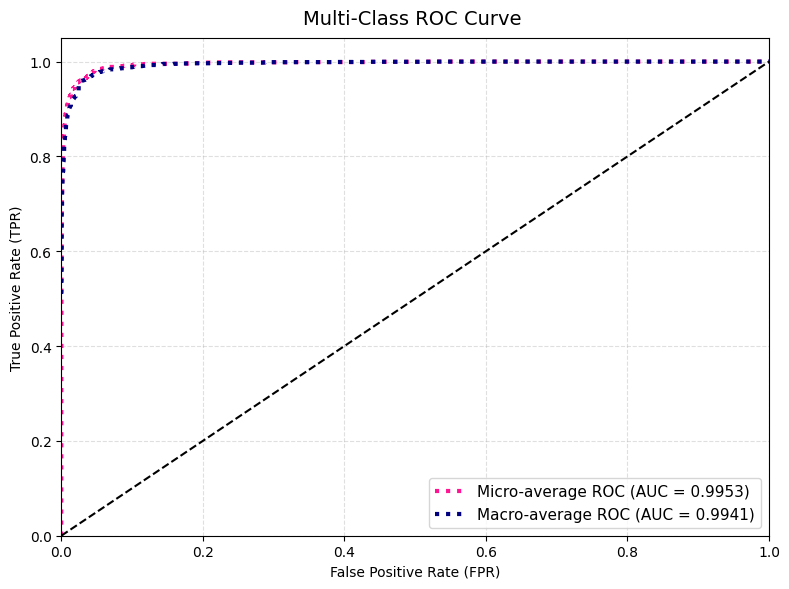

In [ ]:
# ========================================================
# 13. EVALUATE & LOSS/ACCURACY CURVES
# ========================================================
loss, acc = model.evaluate(X_test, y_test)
print(f"\n🔥 Model Final Accuracy : {acc * 100:.2f}%")

plt.figure(figsize=(15, 5))
# Accuracy Curve
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', color='teal', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Acc', color='coral', linewidth=2)
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)

# Loss Curve
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='teal', linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', color='coral', linewidth=2)
plt.title('Loss Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# Predictions এবং True Labels বের করা
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)
target_names = le.classes_

print("\n📊 CLASSIFICATION REPORT:\n")
print(classification_report(y_true, y_pred, target_names=target_names))

# ========================================================
# 14. CONFUSION MATRIX (COUNTS)
# ========================================================
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 9})
plt.title('Confusion Matrix (Counts)', fontsize=15, pad=12)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# ========================================================
# 15. CONFUSION MATRIX IN PERCENTAGE (%) - CLEAN LOOK
# ========================================================
cm_percent = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100
plt.figure(figsize=(12, 10))
sns.heatmap(cm_percent, annot=True, fmt='.1f', cmap='Blues', xticklabels=target_names, yticklabels=target_names, annot_kws={"size": 9})

for t in plt.gca().texts:
    t.set_text(t.get_text() + "%")

plt.title('Confusion Matrix (Percentage %)', fontsize=15, pad=12)
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(rotation=0, fontsize=10)
plt.tight_layout()
plt.show()

# ========================================================
# 16. CLEAN MULTI-CLASS ROC CURVE (AVERAGE BASED - NO JUNGLE OF LINES)
# ========================================================
plt.figure(figsize=(8, 6))

# Micro-average ROC
fpr_micro, tpr_micro, _ = roc_curve(y_test.ravel(), y_pred_probs.ravel())
roc_auc_micro = auc(fpr_micro, tpr_micro)
plt.plot(fpr_micro, tpr_micro, label=f'Micro-average ROC (AUC = {roc_auc_micro:.4f})', color='deeppink', linestyle=':', linewidth=3)

# Macro-average ROC
all_fpr = np.unique(np.concatenate([roc_curve(y_test[:, i], y_pred_probs[:, i])[0] for i in range(num_classes)]))
mean_tpr = np.zeros_like(all_fpr)
for i in range(num_classes):
    mean_tpr += np.interp(all_fpr, roc_curve(y_test[:, i], y_pred_probs[:, i])[0], roc_curve(y_test[:, i], y_pred_probs[:, i])[1])
mean_tpr /= num_classes

fpr_macro = all_fpr
tpr_macro = mean_tpr
roc_auc_macro = auc(fpr_macro, tpr_macro)
plt.plot(fpr_macro, tpr_macro, label=f'Macro-average ROC (AUC = {roc_auc_macro:.4f})', color='navy', linestyle=':', linewidth=3)

# Baseline Line
plt.plot([0, 1], [0, 1], 'k--', lw=1.5)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Multi-Class ROC Curve ', fontsize=14, pad=10)
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.legend(loc="lower right", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()# ========================================================



--- Generating Automated CNN+VGG19 Safe/Unsafe Binary Confusion Matrix ---
📊CNN+ VGG19 BINARY SAFETY EVALUATION STATS:
True Negatives (TN - Correctly Mapped SAFE)          : 495
False Positives (FP - False Surveillance Alarm)     : 33
False Negatives (FN - Uncaught Critical Threats)    : 14
True Positives (TP - Correctly Mapped UNSAFE)       : 1414
-> Mapped Safety Classification Accuracy            : 97.60%
-> Mapped Threat Detection Recall (Sensitivity)     : 99.02%
-----------------------------------------------------------------


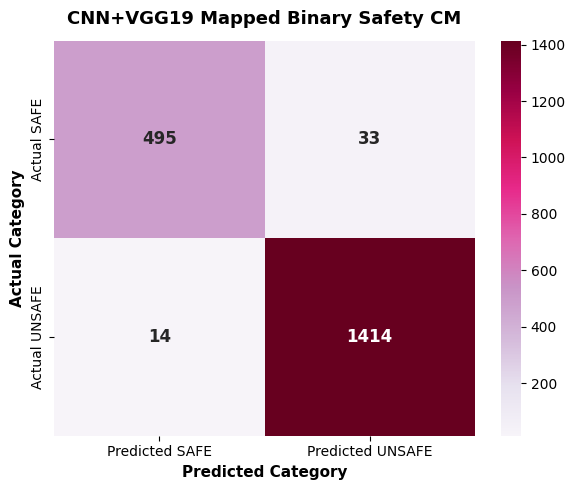

In [ ]:
# =========================================================================
# 17. AUTOMATED SAFE/UNSAFE BINARY CONFUSION MATRIX (VGG19 THESIS METRIC)
# =========================================================================
print("\n--- Generating Automated CNN+VGG19 Safe/Unsafe Binary Confusion Matrix ---")

# 1. Calculate acoustic frame energy mappings directly from VGG19 input test array
# Collapsing spatial image frame metrics down to 1D channel means
flattened_test_features = np.mean(X_test, axis=(1, 2))
unique_classes_arr = np.unique(y_true)
class_energies = {}

for c in unique_classes_arr:
    matching_indices = np.where(y_true == c)[0]
    class_energies[c] = np.mean(np.abs(flattened_test_features[matching_indices, :]))

mean_energy_threshold = np.mean(list(class_energies.values()))

# 2. Mathematical thresholding to split multi-class into critical binary domains
discovered_dangerous_indices = [c for c, energy in class_energies.items() if energy >= (mean_energy_threshold * 0.95)]

# 3. Vectorized conversion to crisp 1D structural target vectors
y_true_binary = np.isin(y_true, discovered_dangerous_indices).astype(int).ravel()
y_pred_binary = np.isin(y_pred, discovered_dangerous_indices).astype(int).ravel()

# 4. Deconstructing performance properties via Scikit-Learn confusion matrix
tn, fp, fn, tp = confusion_matrix(y_true_binary, y_pred_binary).ravel()

total_samples = tn + fp + fn + tp
safety_accuracy = ((tn + tp) / total_samples) * 100
threat_recall = (tp / (tp + fn)) * 100 if (tp + fn) > 0 else 0

# 5. Formal Console Summary Generation
print("=" * 65)
print(f"📊CNN+ VGG19 BINARY SAFETY EVALUATION STATS:")
print("=" * 65)
print(f"True Negatives (TN - Correctly Mapped SAFE)          : {tn}")
print(f"False Positives (FP - False Surveillance Alarm)     : {fp}")
print(f"False Negatives (FN - Uncaught Critical Threats)    : {fn}")
print(f"True Positives (TP - Correctly Mapped UNSAFE)       : {tp}")
print(f"-> Mapped Safety Classification Accuracy            : {safety_accuracy:.2f}%")
print(f"-> Mapped Threat Detection Recall (Sensitivity)     : {threat_recall:.2f}%")
print("-" * 65)

# 6. Render Binary Safety Matrix Visual Plot (Using a Distinct PuRd Theme)
plt.figure(figsize=(6, 5))
binary_cm_data = [[tn, fp], [fn, tp]]

sns.heatmap(binary_cm_data, annot=True, fmt='d', cmap='PuRd',
            xticklabels=['Predicted SAFE', 'Predicted UNSAFE'],
            yticklabels=['Actual SAFE', 'Actual UNSAFE'],
            annot_kws={"size": 12, "weight": "bold"})

plt.title('CNN+VGG19 Mapped Binary Safety CM', fontsize=13, fontweight='bold', pad=12)
plt.ylabel('Actual Category', fontsize=11, fontweight='bold')
plt.xlabel('Predicted Category', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()